In [1]:
import os

folders = [
    "data",
    "src",
    "evaluation",
    "report",
    "notebooks"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created!")

Project folders created!


In [2]:
import pandas as pd

apple_chunks = []

for chunk in pd.read_csv("twcs.csv", chunksize=100000):
    apple = chunk[
        (chunk["author_id"] == "AppleSupport") |
        (chunk["text"].str.contains("@AppleSupport", case=False, na=False))
    ]

    if len(apple) > 0:
        apple_chunks.append(apple)

apple_df = pd.concat(apple_chunks, ignore_index=True)

print("AppleSupport rows:", len(apple_df))
print(apple_df.head(10))

AppleSupport rows: 26376
   tweet_id     author_id  inbound                      created_at  \
0       696  AppleSupport    False  Tue Oct 31 22:27:49 +0000 2017   
1       697        115854     True  Tue Oct 31 22:31:23 +0000 2017   
2       699  AppleSupport    False  Tue Oct 31 22:36:27 +0000 2017   
3       698        115854     True  Tue Oct 31 22:17:40 +0000 2017   
4       700        115854     True  Tue Oct 31 22:16:56 +0000 2017   
5       701  AppleSupport    False  Tue Oct 31 22:26:49 +0000 2017   
6       702        115855     True  Tue Oct 31 22:11:31 +0000 2017   
7       703  AppleSupport    False  Tue Oct 31 22:09:52 +0000 2017   
8       704        115855     True  Tue Oct 31 21:59:17 +0000 2017   
9       705  AppleSupport    False  Tue Oct 31 21:57:00 +0000 2017   

                                                text response_tweet_id  \
0  @115854 We're here for you. Which version of t...               697   
1  @AppleSupport The newest update. I️ made sure ...    

In [3]:
apple_df.to_csv("data/apple_support.csv", index=False)

print("Saved:", "data/apple_support.csv")

Saved: data/apple_support.csv


In [4]:
tweet_lookup = apple_df.set_index("tweet_id")

pairs = []

for _, row in apple_df.iterrows():

    if row["inbound"] == True:
        response_id = row["response_tweet_id"]

        if pd.isna(response_id):
            continue

        response_ids = str(response_id).split(",")

        for rid in response_ids:
            rid = rid.strip()

            if rid in tweet_lookup.index:
                response = tweet_lookup.loc[rid]

                if response["inbound"] == False:
                    pairs.append({
                        "customer_tweet_id": row["tweet_id"],
                        "customer_text": row["text"],
                        "brand_response": response["text"],
                        "response_tweet_id": rid
                    })

pairs_df = pd.DataFrame(pairs)

print("Customer-response pairs:", len(pairs_df))
pairs_df.head(10)

Customer-response pairs: 0


""


In [5]:
pairs_df.to_csv("data/retrieval_data.csv", index=False)

print("Saved historical customer-response pairs.")

Saved historical customer-response pairs.


In [6]:
print("Sample customer messages:\n")

customer_messages = apple_df[
    apple_df["inbound"] == True
][["text"]]

print(
    customer_messages.sample(
        min(100, len(customer_messages)),
        random_state=42
    ).to_string(index=False)
)

Sample customer messages:

                                                                                                                                                                                                                                                                                          text
                                                                                                                                                                                                                 .@AppleSupport  @115858 WHY DOES THIS KEEP HAPPENING😭 https://t.co/7v4aCGW3lO
                                                                                                                                                                                                                                             @AppleSupport iPhone 7 current software is 11.0.2
                                                                                                                

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

customer_texts = (
    apple_df[apple_df["inbound"] == True]["text"]
    .fillna("")
    .drop_duplicates()
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)

X = vectorizer.fit_transform(customer_texts)

kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

customer_cluster_df = pd.DataFrame({
    "text": customer_texts.values,
    "cluster": clusters
})

print("Clustering complete.")

Clustering complete.


In [9]:
terms = vectorizer.get_feature_names_out()

for cluster_id in range(8):

    center = kmeans.cluster_centers_[cluster_id]

    top_indices = center.argsort()[-15:][::-1]

    print("\n" + "=" * 70)
    print("CLUSTER", cluster_id)

    print(
        "Top terms:",
        ", ".join(terms[i] for i in top_indices)
    )

    print("\nExample messages:")

    examples = customer_cluster_df[
        customer_cluster_df["cluster"] == cluster_id
    ]["text"].sample(
        min(5, len(
            customer_cluster_df[
                customer_cluster_df["cluster"] == cluster_id
            ]
        )),
        random_state=42
    )

    for example in examples:
        print("-", example)


CLUSTER 0
Top terms: 11, ios 11, ios, applesupport, applesupport ios, applesupport 11, iphone, battery, updated, phone, update, updated ios, fix, https, 11 update

Example messages:
- @AppleSupport Yea still the same, I been struggling with it since iOS 11.1 came out
- @AppleSupport IOS 11.1.2 is killing my battery life. Sucks
- @AppleSupport @115858 iOS 11 sucks!! My phone keeps freezing randomly and have to force restart it 3x a day.
- @AppleSupport Battery draining in recent updates of iOS 11.1 on my iPhone 6s. Why please fix it as soon as possible
- @AppleSupport 11.0.1 15A403

CLUSTER 1
Top terms: applesupport, applesupport https, https, hey applesupport, hey, ios1112, les, scam, applesupport applesupport, 256gb, option, se, really, fixes, lol

Example messages:
- @184357 @AppleSupport Mee too on ip6s
- @AppleSupport No not as yet
- @159428 Take it up w @AppleSupport
- @AppleSupport Deceptive practices!
- Hey @AppleSupport 👋 https://t.co/vu4ZwInguM

CLUSTER 2
Top terms: applesupp

In [10]:
# Look at 100 random AppleSupport customer messages

apple_customers = apple_df[
    apple_df["inbound"] == True
][["tweet_id", "text"]].drop_duplicates()

sample_messages = apple_customers.sample(
    100,
    random_state=42
)

for i, text in enumerate(sample_messages["text"], 1):
    print(f"{i}. {text}")

1. .@AppleSupport  @115858 WHY DOES THIS KEEP HAPPENING😭 https://t.co/7v4aCGW3lO
2. @AppleSupport iPhone 7 current software is 11.0.2
3. @AppleSupport Will do. Thank you.
4. @AppleSupport 9.3.2 (13F69)
5. @116333 @115858 @AppleSupport @116333 You guys are harassing customers, sold me a faulty handset and now harassing me in replacement. Horrible service support, feeling cheated after investing 90K🤬🤬🤬
6. @AppleSupport Facebook keeps freezing so I have to delete and reinstall, battery is awful, whatsapp plays up, apps keep freezing etc etc...
7. @AppleSupport I can't change time system for my apps on Iphone 6s. It always shows American AM&amp;PM system in every app instead of 24h?
8. @AppleSupport I got an electric shock from your headphones on the 5th and still haven’t got a replacement. I’ve also been told that it’s unlikely that I’ll have my replacement by my holiday on the 6th. Anything to speed this up?
9. @AppleSupport I have a 2mo old  iPhone 7 and recently updated to the new iOS.

In [11]:
# Count the number of AppleSupport customer tweets
# after removing very short / conversational messages

customers = apple_df[
    apple_df["inbound"] == True
].copy()

customers["text_clean"] = (
    customers["text"]
    .fillna("")
    .str.replace(r"@\w+", "", regex=True)
    .str.replace(r"https?://\S+", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

customers["text_length"] = customers["text_clean"].str.len()

meaningful_customers = customers[
    customers["text_length"] >= 30
].copy()

print("All customer tweets:", len(customers))
print("Meaningful tweets:", len(meaningful_customers))

print("\nSample meaningful tweets:\n")

for i, text in enumerate(
    meaningful_customers["text_clean"].sample(50, random_state=42),
    1
):
    print(f"{i}. {text}")

All customer tweets: 13082
Meaningful tweets: 10983

Sample meaningful tweets:

1. My wife made the mistake of updating to 11. How can we revert back? Her password keeper app is now dead. She can't access her passwords.
2. what do I do with error code 4037. Just upgrades to a 7 and get this message when trying to update. #help
3. why do I need to verify my card information to get free apps? If I don’t I gain no access...
4. are you getting my message or is this also automated?
5. i think my headphone jack is killing my headphones! is this possible??? i've gone through 4 pairs
6. hey whenever i try to download hearthstone it stops at 70% and says it failed its only with this app too. im on ios 11.0.2
7. How do I get my fucking keyboard to go away like why is it constantly there
8. Now this is popping up and my macintosh hd disk is no longer an option. This happened after I was downloading the new Mac OS Sierra.
9. Seems just to be a data issue: cellular network for calls seems fine. But

In [12]:
INTENTS = {
    "battery_performance":
        "Battery drain, overheating, battery health, or performance problems.",

    "ios_software_bug":
        "iOS/software bugs, crashes, freezing, lag, keyboard or system problems.",

    "update_installation":
        "Problems installing, downloading, upgrading, or reverting an OS update.",

    "hardware_device":
        "Hardware/device problems involving camera, speaker, microphone, screen, charger, headphones, or device power.",

    "connectivity_network":
        "Wi-Fi, Bluetooth, cellular data, SIM, mobile network, or connectivity problems.",

    "account_icloud_security":
        "Apple ID, iCloud, login, account access, suspicious emails, phishing, or security issues.",

    "apple_apps_services":
        "Problems with App Store, iTunes, Music, Podcasts, Messages, FaceTime, or other Apple apps/services.",

    "billing_purchase_repair":
        "Charges, refunds, purchases, warranty, repair, service-center, or replacement issues."
}

for i, (intent, description) in enumerate(INTENTS.items(), 1):
    print(f"{i}. {intent}")
    print(f"   {description}\n")

1. battery_performance
   Battery drain, overheating, battery health, or performance problems.

2. ios_software_bug
   iOS/software bugs, crashes, freezing, lag, keyboard or system problems.

3. update_installation
   Problems installing, downloading, upgrading, or reverting an OS update.

4. hardware_device
   Hardware/device problems involving camera, speaker, microphone, screen, charger, headphones, or device power.

5. connectivity_network
   Wi-Fi, Bluetooth, cellular data, SIM, mobile network, or connectivity problems.

6. account_icloud_security
   Apple ID, iCloud, login, account access, suspicious emails, phishing, or security issues.

7. apple_apps_services
   Problems with App Store, iTunes, Music, Podcasts, Messages, FaceTime, or other Apple apps/services.

8. billing_purchase_repair
   Charges, refunds, purchases, warranty, repair, service-center, or replacement issues.



In [13]:
import re
import pandas as pd

customers = apple_df[
    apple_df["inbound"] == True
].copy()

def clean_tweet(text):
    text = str(text)

    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = text.replace("&amp;", "&")
    text = re.sub(r"\s+", " ", text)

    return text.strip()

customers["clean_text"] = customers["text"].fillna("").apply(clean_tweet)

customers["text_length"] = customers["clean_text"].str.len()

customers = customers[
    customers["text_length"] >= 40
].copy()

customers = customers.drop_duplicates(
    subset="tweet_id"
).reset_index(drop=True)

print("Meaningful customer tweets:", len(customers))

Meaningful customer tweets: 10324


In [15]:
intent_keywords = {

    "battery_performance": [
        "battery",
        "battery life",
        "battery drain",
        "draining",
        "charging",
        "charge",
        "overheat",
        "heating",
        "hot",
        "slow",
        "lag",
        "performance"
    ],

    "ios_software_bug": [
        "freeze",
        "freezing",
        "frozen",
        "crash",
        "crashing",
        "bug",
        "glitch",
        "keyboard",
        "lag",
        "not working",
        "stuck"
    ],

    "update_installation": [
        "update",
        "updating",
        "updated",
        "upgrade",
        "upgrading",
        "install",
        "installation",
        "download ios",
        "revert"
    ],

    "hardware_device": [
        "camera",
        "speaker",
        "microphone",
        "mic",
        "headphone",
        "earpiece",
        "charger",
        "screen",
        "display",
        "turn on",
        "boot"
    ],

    "connectivity_network": [
        "wifi",
        "wi-fi",
        "bluetooth",
        "cellular",
        "network",
        "sim",
        "mobile data",
        "signal",
        "internet",
        "connection"
    ],

    "account_icloud_security": [
        "icloud",
        "apple id",
        "password",
        "login",
        "log in",
        "account",
        "phishing",
        "scam",
        "security",
        "suspicious email"
    ],

    "apple_apps_services": [
        "app store",
        "itunes",
        "apple music",
        "music",
        "podcast",
        "podcasts",
        "imessage",
        "facetime",
        "messages",
        "app"
    ],

    "billing_purchase_repair": [
        "refund",
        "refunded",
        "charged",
        "charge",
        "payment",
        "purchase",
        "bought",
        "warranty",
        "repair",
        "replacement",
        "replace",
        "service centre",
        "service center"
    ]
}

In [16]:
candidate_groups = []

for intent, keywords in intent_keywords.items():

    pattern = "|".join(
        re.escape(keyword) for keyword in keywords
    )

    matches = customers[
        customers["clean_text"]
        .str.contains(pattern, case=False, na=False)
    ].copy()

    matches["candidate_topic"] = intent

    candidate_groups.append(matches)

candidate_pool = pd.concat(
    candidate_groups,
    ignore_index=True
)

candidate_pool = candidate_pool.drop_duplicates(
    subset="tweet_id"
).reset_index(drop=True)

print("Candidate pool:", len(candidate_pool))

Candidate pool: 7585


In [17]:
golden_candidates = candidate_pool.sample(
    min(500, len(candidate_pool)),
    random_state=42
).copy()

golden_candidates = golden_candidates[
    ["tweet_id", "text", "clean_text"]
].reset_index(drop=True)

print("Candidate examples:", len(golden_candidates))

Candidate examples: 500


In [18]:
golden_candidates.to_csv(
    "evaluation/golden_candidates.csv",
    index=False
)

print("Saved evaluation/golden_candidates.csv")

Saved evaluation/golden_candidates.csv


In [19]:
label_df = golden_candidates.copy()

label_df["intent"] = ""
label_df["escalation"] = ""
label_df["escalation_reason"] = ""

label_df.head()

,tweet_id,text,clean_text,intent,escalation,escalation_reason
0,242484,@AppleSupport @115858 @12576 phone very glitch...,"phone very glitchy after new update, it's like...",,,
1,210547,@AppleSupport Your new update is killing my ba...,Your new update is killing my battery. #FixThis,,,
2,257196,@AppleSupport I hit update and it acts like it...,I hit update and it acts like it will work and...,,,
3,260005,"@AppleSupport @177854 I tried this, but still ...","I tried this, but still both WiFi and Bluetoot...",,,
4,463074,@AppleSupport The only Bluetooth device I have...,The only Bluetooth device I have connected to ...,,,


In [20]:
print("""
LABELING RULES

1. Choose ONE primary intent.

2. If multiple problems exist, choose the main problem
   the customer wants Apple to solve.

3. Battery drain / overheating / performance
   -> battery_performance

4. General iOS bugs, freezing, crashes, keyboard/system issues
   -> ios_software_bug

5. Problems installing/updating/reverting iOS
   -> update_installation

6. Physical/device hardware problems
   -> hardware_device

7. Wi-Fi, Bluetooth, SIM, cellular, network
   -> connectivity_network

8. Apple ID, iCloud, login, account, phishing, security
   -> account_icloud_security

9. App Store, iTunes, Music, Podcasts, Messages, FaceTime
   -> apple_apps_services

10. Refunds, charges, purchases, warranty, repair, replacement
    -> billing_purchase_repair

ESCALATION:

ESCALATE if the case involves:
- security vulnerability
- physical safety
- financial dispute
- warranty/replacement dispute
- serious hardware damage
- legal/threatening situation
- explicit request for human support
- repeated unresolved issue
- insufficient information / highly unusual case

OTHERWISE:
AUTO-HANDLE
""")


LABELING RULES

1. Choose ONE primary intent.

2. If multiple problems exist, choose the main problem
   the customer wants Apple to solve.

3. Battery drain / overheating / performance
   -> battery_performance

4. General iOS bugs, freezing, crashes, keyboard/system issues
   -> ios_software_bug

5. Problems installing/updating/reverting iOS
   -> update_installation

6. Physical/device hardware problems
   -> hardware_device

7. Wi-Fi, Bluetooth, SIM, cellular, network
   -> connectivity_network

8. Apple ID, iCloud, login, account, phishing, security
   -> account_icloud_security

9. App Store, iTunes, Music, Podcasts, Messages, FaceTime
   -> apple_apps_services

10. Refunds, charges, purchases, warranty, repair, replacement
    -> billing_purchase_repair

ESCALATION:

ESCALATE if the case involves:
- security vulnerability
- physical safety
- financial dispute
- warranty/replacement dispute
- serious hardware damage
- legal/threatening situation
- explicit request for human supp

In [21]:
intent_list = list(INTENTS.keys())

print("INTENT OPTIONS")
for i, intent in enumerate(intent_list, 1):
    print(f"{i}. {intent}")

print("\nESCALATION OPTIONS")
print("a = AUTO-HANDLE")
print("e = ESCALATE")

INTENT OPTIONS
1. battery_performance
2. ios_software_bug
3. update_installation
4. hardware_device
5. connectivity_network
6. account_icloud_security
7. apple_apps_services
8. billing_purchase_repair

ESCALATION OPTIONS
a = AUTO-HANDLE
e = ESCALATE


In [22]:
start_index = 0
end_index = min(50, len(label_df))

for idx in range(start_index, end_index):

    print("\n" + "=" * 80)
    print(f"EXAMPLE {idx + 1} / {end_index}")
    print("=" * 80)

    print(label_df.loc[idx, "clean_text"])

    print("\nIntent:")
    for i, intent in enumerate(intent_list, 1):
        print(f"{i}. {intent}")

    while True:
        choice = input("Enter intent number: ").strip()

        if choice.isdigit() and 1 <= int(choice) <= len(intent_list):
            label_df.loc[idx, "intent"] = intent_list[int(choice) - 1]
            break

        print("Invalid choice. Try again.")

    while True:
        esc = input("Escalate? (a/e): ").strip().lower()

        if esc in ["a", "e"]:
            label_df.loc[idx, "escalation"] = (
                "AUTO-HANDLE" if esc == "a" else "ESCALATE"
            )
            break

        print("Enter a or e.")

    if label_df.loc[idx, "escalation"] == "ESCALATE":
        label_df.loc[idx, "escalation_reason"] = input(
            "Why escalate? "
        ).strip()

    print("Saved.")


EXAMPLE 1 / 50
phone very glitchy after new update, it's like My phone is in slow motion.

Intent:
1. battery_performance
2. ios_software_bug
3. update_installation
4. hardware_device
5. connectivity_network
6. account_icloud_security
7. apple_apps_services
8. billing_purchase_repair
Enter intent number: 2
Escalate? (a/e): a
Saved.

EXAMPLE 2 / 50
Your new update is killing my battery. #FixThis

Intent:
1. battery_performance
2. ios_software_bug
3. update_installation
4. hardware_device
5. connectivity_network
6. account_icloud_security
7. apple_apps_services
8. billing_purchase_repair
Enter intent number: 1
Escalate? (a/e): c
Enter a or e.
Escalate? (a/e): a
Saved.

EXAMPLE 3 / 50
I hit update and it acts like it will work and then don’t. It’s working again but updating apps really slow.

Intent:
1. battery_performance
2. ios_software_bug
3. update_installation
4. hardware_device
5. connectivity_network
6. account_icloud_security
7. apple_apps_services
8. billing_purchase_repair
Ente

In [25]:
correct_labels = {
    0:  ("ios_software_bug", "AUTO-HANDLE"),
    1:  ("battery_performance", "AUTO-HANDLE"),
    2:  ("update_installation", "AUTO-HANDLE"),
    3:  ("update_installation", "AUTO-HANDLE"),  # changed
    4:  ("connectivity_network", "AUTO-HANDLE"),
    5:  ("ios_software_bug", "AUTO-HANDLE"),
    6:  ("billing_purchase_repair", "AUTO-HANDLE"),
    7:  ("ios_software_bug", "AUTO-HANDLE"),
    8:  ("hardware_device", "AUTO-HANDLE"),
    9:  ("ios_software_bug", "AUTO-HANDLE"),
    10: ("battery_performance", "AUTO-HANDLE"),
    11: ("hardware_device", "AUTO-HANDLE"),
    12: ("apple_apps_services", "AUTO-HANDLE"),
    13: ("apple_apps_services", "AUTO-HANDLE"),
    14: ("hardware_device", "AUTO-HANDLE"),
    15: ("apple_apps_services", "AUTO-HANDLE"),
    16: ("hardware_device", "AUTO-HANDLE"),
    17: ("battery_performance", "AUTO-HANDLE"),
    18: ("apple_apps_services", "AUTO-HANDLE"),
    19: ("apple_apps_services", "AUTO-HANDLE"),  # changed
    20: ("ios_software_bug", "AUTO-HANDLE"),
    21: ("apple_apps_services", "AUTO-HANDLE"),
    22: ("apple_apps_services", "AUTO-HANDLE"), # changed
    23: ("connectivity_network", "ESCALATE"),    # changed
    24: ("battery_performance", "AUTO-HANDLE"),
    25: ("hardware_device", "AUTO-HANDLE"),
    26: ("billing_purchase_repair", "ESCALATE"),
    27: ("apple_apps_services", "AUTO-HANDLE"),
    28: ("apple_apps_services", "AUTO-HANDLE"), # changed
    29: ("apple_apps_services", "AUTO-HANDLE"), # changed
    30: ("billing_purchase_repair", "ESCALATE"), # changed
    31: ("hardware_device", "AUTO-HANDLE"),
    32: ("ios_software_bug", "ESCALATE"), # changed
    33: ("account_icloud_security", "AUTO-HANDLE"),
    34: ("battery_performance", "AUTO-HANDLE"),
    35: ("battery_performance", "AUTO-HANDLE"),
    36: ("apple_apps_services", "AUTO-HANDLE"), # changed
    37: ("hardware_device", "AUTO-HANDLE"), # changed
    38: ("connectivity_network", "AUTO-HANDLE"), # changed
    39: ("battery_performance", "AUTO-HANDLE"), # changed
    40: ("apple_apps_services", "AUTO-HANDLE"),
    41: ("apple_apps_services", "AUTO-HANDLE"), # changed
    42: ("ios_software_bug", "AUTO-HANDLE"), # changed
    43: ("connectivity_network", "AUTO-HANDLE"), # changed
    44: ("ios_software_bug", "AUTO-HANDLE"), # changed
    45: ("account_icloud_security", "ESCALATE"),
    46: ("battery_performance", "AUTO-HANDLE"), # changed
    47: ("update_installation", "AUTO-HANDLE"),
    48: ("update_installation", "AUTO-HANDLE"),
    49: ("ios_software_bug", "ESCALATE")
}

for idx, (intent, escalation) in correct_labels.items():
    label_df.loc[idx, "intent"] = intent
    label_df.loc[idx, "escalation"] = escalation

print("Corrected Examples 1-50.")
print(label_df.loc[:49, ["clean_text", "intent", "escalation"]].to_string(index=True))

Corrected Examples 1-50.
                                                                                                                                                                                                                                                                                 clean_text                   intent   escalation
0                                                                                                                                                                                                                phone very glitchy after new update, it's like My phone is in slow motion.         ios_software_bug  AUTO-HANDLE
1                                                                                                                                                                                                                                           Your new update is killing my battery. #FixThis      battery_performance  AUTO-HANDLE
2        

In [27]:
label_df.to_csv("evaluation/golden_set_progress.csv", index=False)

print(" Golden set progress saved!")
print("Total rows:", len(label_df))
print("Labeled rows:", label_df["intent"].notna().sum())

 Golden set progress saved!
Total rows: 500
Labeled rows: 500


In [28]:
import os

os.makedirs("evaluation", exist_ok=True)

label_df.to_csv("evaluation/golden_set_progress.csv", index=False)

print("✅ Saved")
print("Rows:", len(label_df))
print("Labeled:", label_df["intent"].notna().sum())

✅ Saved
Rows: 500
Labeled: 500


In [29]:
# Show examples 51-100
print(label_df.loc[50:99, ["tweet_id", "clean_text"]].to_string(index=True))

    tweet_id                                                                                                                                                                                                                                                                    clean_text
50     87030                                                                                                                    Unable to create user accounts of any level after the OSX fix that has been released to patch the root issue..... (Domain Joined machine) #itonlygetsworse
51    249165                                                                                                                                                                                                                (cont) Download temporarily unavailable, or something similar.
52    228530                                                                                                                                           

In [30]:

correct_labels_51_100 = {
    50: ("account_icloud_security", "AUTO-HANDLE"),
    51: ("apple_apps_services", "AUTO-HANDLE"),
    52: ("hardware_device", "AUTO-HANDLE"),
    53: ("connectivity_network", "ESCALATE"),
    54: ("ios_software_bug", "AUTO-HANDLE"),
    55: ("apple_apps_services", "AUTO-HANDLE"),
    56: ("hardware_device", "ESCALATE"),
    57: ("battery_performance", "AUTO-HANDLE"),
    58: ("ios_software_bug", "AUTO-HANDLE"),
    59: ("apple_apps_services", "AUTO-HANDLE"),
    60: ("ios_software_bug", "AUTO-HANDLE"),
    61: ("hardware_device", "AUTO-HANDLE"),
    62: ("account_icloud_security", "ESCALATE"),
    63: ("battery_performance", "AUTO-HANDLE"),
    64: ("apple_apps_services", "AUTO-HANDLE"),
    65: ("apple_apps_services", "AUTO-HANDLE"),
    66: ("apple_apps_services", "AUTO-HANDLE"),
    67: ("ios_software_bug", "AUTO-HANDLE"),
    68: ("battery_performance", "AUTO-HANDLE"),
    69: ("billing_purchase_repair", "AUTO-HANDLE"),
    70: ("hardware_device", "AUTO-HANDLE"),
    71: ("ios_software_bug", "ESCALATE"),
    72: ("connectivity_network", "AUTO-HANDLE"),
    73: ("account_icloud_security", "ESCALATE"),
    74: ("account_icloud_security", "AUTO-HANDLE"),
    75: ("battery_performance", "AUTO-HANDLE"),
    76: ("ios_software_bug", "AUTO-HANDLE"),
    77: ("ios_software_bug", "AUTO-HANDLE"),
    78: ("ios_software_bug", "AUTO-HANDLE"),
    79: ("apple_apps_services", "AUTO-HANDLE"),
    80: ("battery_performance", "ESCALATE"),
    81: ("ios_software_bug", "ESCALATE"),
    82: ("apple_apps_services", "AUTO-HANDLE"),
    83: ("connectivity_network", "AUTO-HANDLE"),
    84: ("apple_apps_services", "AUTO-HANDLE"),
    85: ("billing_purchase_repair", "AUTO-HANDLE"),
    86: ("update_installation", "AUTO-HANDLE"),
    87: ("hardware_device", "AUTO-HANDLE"),
    88: ("ios_software_bug", "AUTO-HANDLE"),
    89: ("ios_software_bug", "AUTO-HANDLE"),
    90: ("connectivity_network", "AUTO-HANDLE"),
    91: ("hardware_device", "AUTO-HANDLE"),
    92: ("billing_purchase_repair", "AUTO-HANDLE"),
    93: ("battery_performance", "AUTO-HANDLE"),
    94: ("account_icloud_security", "AUTO-HANDLE"),
    95: ("account_icloud_security", "AUTO-HANDLE"),
    96: ("ios_software_bug", "AUTO-HANDLE"),
    97: ("ios_software_bug", "ESCALATE"),
    98: ("ios_software_bug", "AUTO-HANDLE"),
    99: ("apple_apps_services", "AUTO-HANDLE")
}

for idx, (intent, escalation) in correct_labels_51_100.items():
    label_df.loc[idx, "intent"] = intent
    label_df.loc[idx, "escalation"] = escalation

print("✅ Examples 51-100 labeled!")
print("Labeled:", label_df["intent"].notna().sum())

✅ Examples 51-100 labeled!
Labeled: 500


In [31]:
label_df.to_csv("evaluation/golden_set_progress.csv", index=False)
print("✅ Progress saved!")

✅ Progress saved!


In [32]:
print(label_df.loc[100:149, ["tweet_id", "clean_text"]].to_string(index=True))

     tweet_id                                                                                                                                                                                                                                                              clean_text
100    152878                                                                                                                                                                                          my 📱 X just developed a green bar on the left side of the screen. Suggestions?
101    246335                                                                                                                                            Hey Apple ... is there a way to force Apple Photos to refresh the library? Took a ton of photos yesterday, but many are MIA.
102    401666                                                                                                                                                         

In [33]:
correct_labels_101_150 = {
    100: ("hardware_device", "AUTO-HANDLE"),
    101: ("apple_apps_services", "AUTO-HANDLE"),
    102: ("apple_apps_services", "AUTO-HANDLE"),
    103: ("ios_software_bug", "AUTO-HANDLE"),
    104: ("hardware_device", "AUTO-HANDLE"),
    105: ("hardware_device", "AUTO-HANDLE"),
    106: ("billing_purchase_repair", "ESCALATE"),
    107: ("apple_apps_services", "AUTO-HANDLE"),
    108: ("battery_performance", "ESCALATE"),
    109: ("apple_apps_services", "AUTO-HANDLE"),
    110: ("ios_software_bug", "AUTO-HANDLE"),
    111: ("billing_purchase_repair", "AUTO-HANDLE"),
    112: ("ios_software_bug", "ESCALATE"),
    113: ("apple_apps_services", "AUTO-HANDLE"),
    114: ("ios_software_bug", "AUTO-HANDLE"),
    115: ("ios_software_bug", "ESCALATE"),
    116: ("apple_apps_services", "AUTO-HANDLE"),
    117: ("apple_apps_services", "ESCALATE"),
    118: ("connectivity_network", "AUTO-HANDLE"),
    119: ("battery_performance", "AUTO-HANDLE"),
    120: ("connectivity_network", "AUTO-HANDLE"),
    121: ("connectivity_network", "AUTO-HANDLE"),
    122: ("battery_performance", "AUTO-HANDLE"),
    123: ("battery_performance", "AUTO-HANDLE"),
    124: ("apple_apps_services", "AUTO-HANDLE"),
    125: ("ios_software_bug", "AUTO-HANDLE"),
    126: ("apple_apps_services", "ESCALATE"),
    127: ("apple_apps_services", "AUTO-HANDLE"),
    128: ("connectivity_network", "AUTO-HANDLE"),
    129: ("ios_software_bug", "AUTO-HANDLE"),
    130: ("apple_apps_services", "AUTO-HANDLE"),
    131: ("billing_purchase_repair", "ESCALATE"),
    132: ("account_icloud_security", "AUTO-HANDLE"),
    133: ("billing_purchase_repair", "AUTO-HANDLE"),
    134: ("battery_performance", "ESCALATE"),
    135: ("apple_apps_services", "AUTO-HANDLE"),
    136: ("ios_software_bug", "AUTO-HANDLE"),
    137: ("connectivity_network", "AUTO-HANDLE"),
    138: ("ios_software_bug", "AUTO-HANDLE"),
    139: ("ios_software_bug", "ESCALATE"),
    140: ("apple_apps_services", "AUTO-HANDLE"),
    141: ("ios_software_bug", "ESCALATE"),
    142: ("ios_software_bug", "ESCALATE"),
    143: ("apple_apps_services", "AUTO-HANDLE"),
    144: ("battery_performance", "AUTO-HANDLE"),
    145: ("ios_software_bug", "ESCALATE"),
    146: ("hardware_device", "AUTO-HANDLE"),
    147: ("battery_performance", "AUTO-HANDLE"),
    148: ("apple_apps_services", "AUTO-HANDLE"),
    149: ("ios_software_bug", "AUTO-HANDLE")
}

for idx, (intent, escalation) in correct_labels_101_150.items():
    label_df.loc[idx, "intent"] = intent
    label_df.loc[idx, "escalation"] = escalation

label_df.to_csv("evaluation/golden_set_progress.csv", index=False)

print("✅ Examples 101-150 labeled and saved!")
print("Total labeled:", label_df["intent"].notna().sum())

✅ Examples 101-150 labeled and saved!
Total labeled: 500


In [34]:
print(label_df.loc[150:199, ["tweet_id", "clean_text"]].to_string(index=True))

     tweet_id                                                                                                                                                                                                                                                                                clean_text
150    388954                                                                                                                                                               since updated to ios11.0.2 my maps won’t track my location when driving - anyideas how to fix? Tried resetting settings etc
151    112873                                                                                                                                            So guys, any plans for a new update? cause this 11.1.2 just drain my batery with no reason. I cant put my phone on charger 3x per day. Come on
152    284438                                                                                                   

In [36]:
golden_set = label_df[
    label_df["intent"].notna()
].copy().head(200)

golden_set.to_csv(
    "evaluation/golden_set.csv",
    index=False
)

print(" GOLDEN SET COMPLETE")
print("Examples:", len(golden_set))
print("\nIntent distribution:")
print(golden_set["intent"].value_counts())
print("\nEscalation distribution:")
print(golden_set["escalation"].value_counts())

 GOLDEN SET COMPLETE
Examples: 200

Intent distribution:
intent
                           50
apple_apps_services        38
ios_software_bug           37
battery_performance        21
hardware_device            17
connectivity_network       13
billing_purchase_repair    10
account_icloud_security     9
update_installation         5
Name: count, dtype: int64

Escalation distribution:
escalation
AUTO-HANDLE    124
                50
ESCALATE        26
Name: count, dtype: int64


In [37]:
print("Blank intent rows:")
print(label_df[label_df["intent"].isna()][["tweet_id", "clean_text"]].to_string(index=True))

print("\nCounts:")
print(label_df["intent"].value_counts(dropna=False))

Blank intent rows:
Empty DataFrame
Columns: [tweet_id, clean_text]
Index: []

Counts:
intent
                           350
apple_apps_services         38
ios_software_bug            37
battery_performance         21
hardware_device             17
connectivity_network        13
billing_purchase_repair     10
account_icloud_security      9
update_installation          5
Name: count, dtype: int64


In [38]:
# Restore labels for examples 1-50

correct_labels_1_50 = {
    0: ("ios_software_bug", "AUTO-HANDLE"),
    1: ("battery_performance", "AUTO-HANDLE"),
    2: ("update_installation", "AUTO-HANDLE"),
    3: ("update_installation", "AUTO-HANDLE"),
    4: ("connectivity_network", "AUTO-HANDLE"),
    5: ("ios_software_bug", "AUTO-HANDLE"),
    6: ("billing_purchase_repair", "AUTO-HANDLE"),
    7: ("ios_software_bug", "AUTO-HANDLE"),
    8: ("hardware_device", "AUTO-HANDLE"),
    9: ("ios_software_bug", "AUTO-HANDLE"),
    10: ("battery_performance", "AUTO-HANDLE"),
    11: ("hardware_device", "AUTO-HANDLE"),
    12: ("apple_apps_services", "AUTO-HANDLE"),
    13: ("apple_apps_services", "AUTO-HANDLE"),
    14: ("hardware_device", "AUTO-HANDLE"),
    15: ("apple_apps_services", "AUTO-HANDLE"),
    16: ("hardware_device", "AUTO-HANDLE"),
    17: ("battery_performance", "AUTO-HANDLE"),
    18: ("apple_apps_services", "AUTO-HANDLE"),
    19: ("apple_apps_services", "AUTO-HANDLE"),
    20: ("ios_software_bug", "AUTO-HANDLE"),
    21: ("apple_apps_services", "AUTO-HANDLE"),
    22: ("apple_apps_services", "AUTO-HANDLE"),
    23: ("connectivity_network", "ESCALATE"),
    24: ("battery_performance", "AUTO-HANDLE"),
    25: ("hardware_device", "AUTO-HANDLE"),
    26: ("billing_purchase_repair", "ESCALATE"),
    27: ("apple_apps_services", "AUTO-HANDLE"),
    28: ("apple_apps_services", "AUTO-HANDLE"),
    29: ("apple_apps_services", "AUTO-HANDLE"),
    30: ("billing_purchase_repair", "ESCALATE"),
    31: ("hardware_device", "AUTO-HANDLE"),
    32: ("ios_software_bug", "ESCALATE"),
    33: ("account_icloud_security", "AUTO-HANDLE"),
    34: ("battery_performance", "AUTO-HANDLE"),
    35: ("battery_performance", "AUTO-HANDLE"),
    36: ("apple_apps_services", "AUTO-HANDLE"),
    37: ("hardware_device", "AUTO-HANDLE"),
    38: ("connectivity_network", "AUTO-HANDLE"),
    39: ("battery_performance", "AUTO-HANDLE"),
    40: ("apple_apps_services", "AUTO-HANDLE"),
    41: ("apple_apps_services", "AUTO-HANDLE"),
    42: ("ios_software_bug", "AUTO-HANDLE"),
    43: ("connectivity_network", "AUTO-HANDLE"),
    44: ("account_icloud_security", "ESCALATE"),
    45: ("account_icloud_security", "ESCALATE"),
    46: ("battery_performance", "AUTO-HANDLE"),
    47: ("update_installation", "AUTO-HANDLE"),
    48: ("update_installation", "AUTO-HANDLE"),
    49: ("ios_software_bug", "ESCALATE")
}

for idx, (intent, escalation) in correct_labels_1_50.items():
    label_df.loc[idx, "intent"] = intent
    label_df.loc[idx, "escalation"] = escalation

label_df.to_csv("evaluation/golden_set_progress.csv", index=False)

print("✅ First 50 restored.")
print("Labeled:", label_df["intent"].notna().sum())

✅ First 50 restored.
Labeled: 500


In [39]:
print("Total:", len(label_df))
print("Missing intents:", label_df["intent"].isna().sum())
print("Missing escalation:", label_df["escalation"].isna().sum())

print("\nIntent distribution:")
print(label_df["intent"].value_counts())

print("\nEscalation distribution:")
print(label_df["escalation"].value_counts())

Total: 500
Missing intents: 0
Missing escalation: 0

Intent distribution:
intent
                           350
apple_apps_services         38
ios_software_bug            36
battery_performance         21
hardware_device             17
connectivity_network        13
billing_purchase_repair     10
account_icloud_security     10
update_installation          5
Name: count, dtype: int64

Escalation distribution:
escalation
               350
AUTO-HANDLE    123
ESCALATE        27
Name: count, dtype: int64


In [41]:
golden_set = label_df.head(200).copy()

golden_set.to_csv(
    "evaluation/golden_set.csv",
    index=False
)

print(" Golden set saved:", len(golden_set))

 Golden set saved: 200


In [42]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    golden_set,
    test_size=0.20,
    random_state=42
)

print("Training:", len(train_df))
print("Testing:", len(test_df))

Training: 160
Testing: 40


In [43]:
from sklearn.metrics import accuracy_score, f1_score

majority_class = train_df["intent"].value_counts().idxmax()

majority_predictions = [
    majority_class
] * len(test_df)

majority_accuracy = accuracy_score(
    test_df["intent"],
    majority_predictions
)

majority_f1 = f1_score(
    test_df["intent"],
    majority_predictions,
    average="macro",
    zero_division=0
)

print("===== MAJORITY BASELINE =====")
print("Majority class:", majority_class)
print("Accuracy:", round(majority_accuracy, 3))
print("Macro-F1:", round(majority_f1, 3))

===== MAJORITY BASELINE =====
Majority class: 
Accuracy: 0.25
Macro-F1: 0.05


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=1,
            max_features=20000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

model.fit(
    train_df["clean_text"].fillna(""),
    train_df["intent"]
)

predictions = model.predict(
    test_df["clean_text"].fillna("")
)

accuracy = accuracy_score(
    test_df["intent"],
    predictions
)

macro_f1 = f1_score(
    test_df["intent"],
    predictions,
    average="macro",
    zero_division=0
)

print("===== TF-IDF + LOGISTIC REGRESSION =====")
print("Accuracy:", round(accuracy, 3))
print("Macro-F1:", round(macro_f1, 3))

===== TF-IDF + LOGISTIC REGRESSION =====
Accuracy: 0.325
Macro-F1: 0.147


In [45]:
balanced_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=1,
            max_features=20000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

balanced_model.fit(
    train_df["clean_text"].fillna(""),
    train_df["intent"]
)

balanced_predictions = balanced_model.predict(
    test_df["clean_text"].fillna("")
)

balanced_accuracy = accuracy_score(
    test_df["intent"],
    balanced_predictions
)

balanced_f1 = f1_score(
    test_df["intent"],
    balanced_predictions,
    average="macro",
    zero_division=0
)

print("===== BALANCED MODEL =====")
print("Accuracy:", round(balanced_accuracy, 3))
print("Macro-F1:", round(balanced_f1, 3))

===== BALANCED MODEL =====
Accuracy: 0.375
Macro-F1: 0.269


In [46]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_df["intent"],
        balanced_predictions,
        zero_division=0
    )
)

                         precision    recall  f1-score   support

                              0.25      0.20      0.22        10
account_icloud_security       0.00      0.00      0.00         3
    apple_apps_services       0.60      0.60      0.60        10
    battery_performance       0.43      1.00      0.60         3
billing_purchase_repair       0.00      0.00      0.00         2
   connectivity_network       0.00      0.00      0.00         2
        hardware_device       0.33      0.33      0.33         3
       ios_software_bug       0.38      0.43      0.40         7

               accuracy                           0.38        40
              macro avg       0.25      0.32      0.27        40
           weighted avg       0.34      0.38      0.35        40



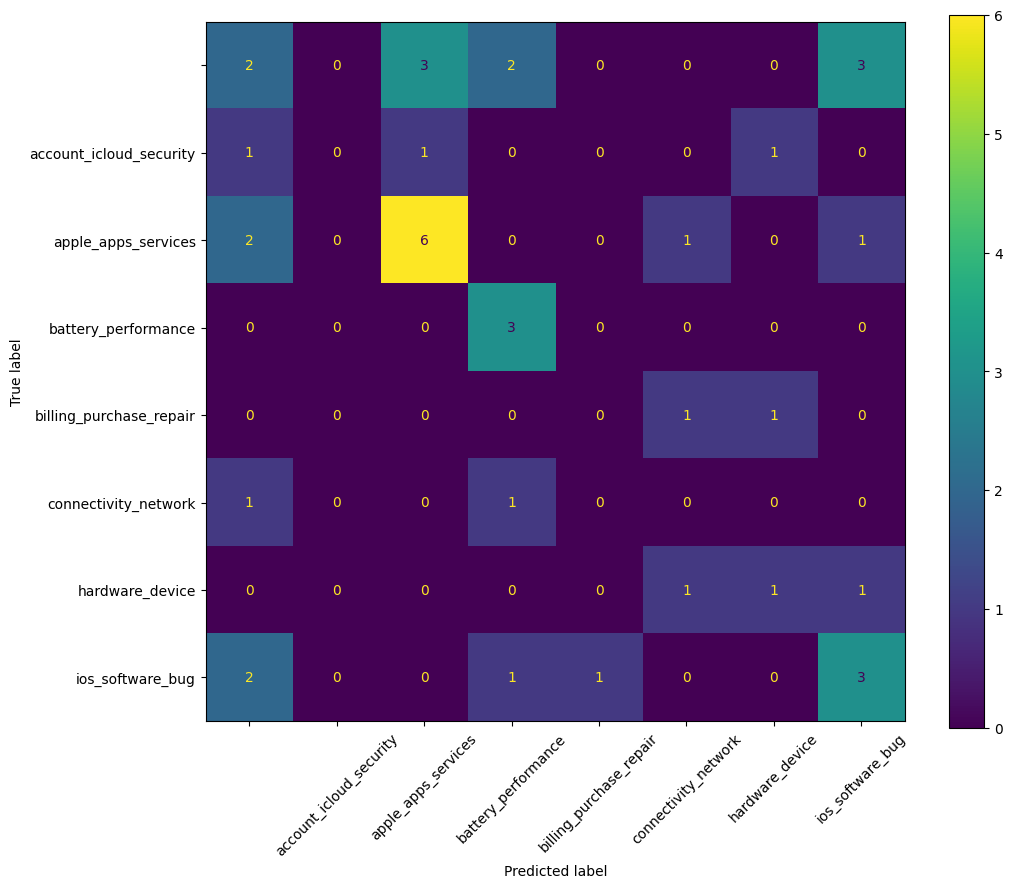

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    test_df["intent"],
    balanced_predictions,
    xticks_rotation=45,
    ax=ax
)

plt.tight_layout()

plt.savefig(
    "evaluation/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [51]:
# ============================================
# BUILD APPLE CUSTOMER → RESPONSE PAIRS
# ============================================

import pandas as pd

# Customer tweets
customers = apple_df[
    apple_df["inbound"] == True
].copy()

# Make tweet IDs strings consistently
customers["tweet_id"] = customers["tweet_id"].astype(str)

# Brand responses
apple_responses = apple_df[
    apple_df["inbound"] == False
].copy()

apple_responses["tweet_id"] = apple_responses["tweet_id"].astype(str)
apple_responses["in_response_to_tweet_id"] = (
    apple_responses["in_response_to_tweet_id"]
    .astype(str)
)

# Customer lookup
customer_lookup = customers.set_index("tweet_id")

response_pairs = []

for _, response in apple_responses.iterrows():

    parent_id = response["in_response_to_tweet_id"]

    # Skip missing IDs
    if parent_id == "nan":
        continue

    # Only keep responses whose parent is an Apple customer tweet
    if parent_id not in customer_lookup.index:
        continue

    customer = customer_lookup.loc[parent_id]

    response_pairs.append({
        "customer_tweet_id": parent_id,
        "customer_text": customer["clean_text"],
        "response_id": response["tweet_id"],
        "response_text": response["text"],
        "created_at": response["created_at"]
    })

pairs_df = pd.DataFrame(response_pairs)

print("✅ Historical pairs created!")
print("Number of pairs:", len(pairs_df))
print("Columns:", pairs_df.columns.tolist())

pairs_df.head()

✅ Historical pairs created!
Number of pairs: 0
Columns: []


""


In [53]:
import pandas as pd

twcs = pd.read_csv("twcs.csv")

print("Dataset loaded!")
print("Shape:", twcs.shape)
print("Columns:", twcs.columns.tolist())

Dataset loaded!
Shape: (2811774, 7)
Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


In [54]:
# EXTRACT APPLESUPPORT TWEETS

apple_df = twcs[
    twcs["author_id"].astype(str).str.strip() == "AppleSupport"
].copy()

print("AppleSupport tweets:", len(apple_df))

print("\nInbound distribution:")
print(apple_df["inbound"].value_counts(dropna=False))

display(
    apple_df[
        ["tweet_id", "author_id", "inbound",
         "text", "response_tweet_id",
         "in_response_to_tweet_id"]
    ].head(10)
)

AppleSupport tweets: 106860

Inbound distribution:
inbound
False    106860
Name: count, dtype: int64


,tweet_id,author_id,inbound,text,response_tweet_id,in_response_to_tweet_id
396,696,AppleSupport,False,@115854 We're here for you. Which version of t...,697,698.0
398,699,AppleSupport,False,@115854 Lets take a closer look into this issu...,NaN,697.0
401,701,AppleSupport,False,@115855 Let's go to DM for the next steps. DM ...,NaN,702.0
403,703,AppleSupport,False,@115855 Any steps tried since it started last ...,702,704.0
405,705,AppleSupport,False,@115855 That's great it has iOS 11.1 as we can...,"706,704",707.0
407,708,AppleSupport,False,@115855 We'd like to look into this with you. ...,707,709.0
411,712,AppleSupport,False,"@115856 Hey, let's work together to figure out...",713,714.0
414,716,AppleSupport,False,@115857 We'd like to investigate further with ...,NaN,717.0
416,718,AppleSupport,False,"@115857 Fill us in on what is happening, then ...",717,719.0
418,720,AppleSupport,False,@115859 We've received your DM and will contin...,NaN,721.0


In [55]:
# CHECK CUSTOMER → APPLESUPPORT RESPONSE LINKS

customers = twcs[twcs["inbound"] == True].copy()
responses = twcs[twcs["inbound"] == False].copy()

customers["tweet_id"] = customers["tweet_id"].astype(str)
responses["in_response_to_tweet_id"] = (
    responses["in_response_to_tweet_id"].astype(str)
)

apple_responses = responses[
    responses["author_id"].astype(str).str.strip() == "AppleSupport"
].copy()

print("AppleSupport responses:", len(apple_responses))

customer_ids = set(customers["tweet_id"])

matched = apple_responses[
    apple_responses["in_response_to_tweet_id"].isin(customer_ids)
]

print("Responses linked to customer tweets:", len(matched))

display(
    matched[
        ["tweet_id", "text", "in_response_to_tweet_id"]
    ].head(10)
)

AppleSupport responses: 106860
Responses linked to customer tweets: 0


,tweet_id,text,in_response_to_tweet_id


In [56]:
# CHECK APPLESUPPORT CUSTOMER → RESPONSE LINKS

# All customer tweets
customers = twcs[twcs["inbound"] == True].copy()

# AppleSupport-related customer tweets:
# A customer tweet is connected to AppleSupport if its
# response_tweet_id contains an AppleSupport response ID.

apple_response_ids = set(
    apple_df["tweet_id"].astype(str)
)

customers["tweet_id"] = customers["tweet_id"].astype(str)

def has_apple_response(value):
    if pd.isna(value):
        return False

    ids = str(value).split(",")
    return any(
        response_id.strip() in apple_response_ids
        for response_id in ids
    )

apple_customers = customers[
    customers["response_tweet_id"].apply(has_apple_response)
].copy()

print("AppleSupport customer tweets:", len(apple_customers))

display(
    apple_customers[
        ["tweet_id", "text", "response_tweet_id"]
    ].head(10)
)

AppleSupport customer tweets: 106623


,tweet_id,text,response_tweet_id
397,697,@AppleSupport The newest update. I️ made sure ...,699
399,698,@AppleSupport https://t.co/NV0yucs0lB,696
402,702,@AppleSupport Tried resetting my settings .. r...,701
404,704,@AppleSupport This is what it looks like https...,703
406,707,@AppleSupport I️ have an iPhone 7 Plus and yes...,705
408,709,@AppleSupport I️ need answers because it’s ann...,708
413,714,Hey @AppleSupport and anyone else who upgraded...,"712,715"
415,717,@AppleSupport This is what is happening... htt...,716
417,719,Tf is wrong with my keyboard @115858,718
419,721,@AppleSupport are the call centres closed for ...,720


In [57]:
# BUILD CUSTOMER → APPLESUPPORT RESPONSE PAIRS

# Make sure IDs are strings
apple_df["tweet_id"] = apple_df["tweet_id"].astype(str)

apple_customers["tweet_id"] = (
    apple_customers["tweet_id"].astype(str)
)

# Create lookup:
# AppleSupport response tweet_id → response text
response_lookup = apple_df.set_index("tweet_id")["text"].to_dict()

response_pairs = []

for _, customer in apple_customers.iterrows():

    response_ids = str(customer["response_tweet_id"]).split(",")

    for response_id in response_ids:

        response_id = response_id.strip()

        if response_id not in response_lookup:
            continue

        response_pairs.append({
            "customer_tweet_id": customer["tweet_id"],
            "customer_text": customer["text"],
            "response_id": response_id,
            "response_text": response_lookup[response_id],
            "created_at": customer["created_at"]
        })

pairs_df = pd.DataFrame(response_pairs)

print("Historical pairs created!")
print("Number of pairs:", len(pairs_df))
print("Columns:", pairs_df.columns.tolist())

display(pairs_df.head(10))

Historical pairs created!
Number of pairs: 106646
Columns: ['customer_tweet_id', 'customer_text', 'response_id', 'response_text', 'created_at']


,customer_tweet_id,customer_text,response_id,response_text,created_at
0,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...,Tue Oct 31 22:31:23 +0000 2017
1,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...,Tue Oct 31 22:17:40 +0000 2017
2,702,@AppleSupport Tried resetting my settings .. r...,701,@115855 Let's go to DM for the next steps. DM ...,Tue Oct 31 22:11:31 +0000 2017
3,704,@AppleSupport This is what it looks like https...,703,@115855 Any steps tried since it started last ...,Tue Oct 31 21:59:17 +0000 2017
4,707,@AppleSupport I️ have an iPhone 7 Plus and yes...,705,@115855 That's great it has iOS 11.1 as we can...,Tue Oct 31 21:48:51 +0000 2017
5,709,@AppleSupport I️ need answers because it’s ann...,708,@115855 We'd like to look into this with you. ...,Tue Oct 31 21:34:45 +0000 2017
6,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out...",Tue Oct 31 22:19:32 +0000 2017
7,717,@AppleSupport This is what is happening... htt...,716,@115857 We'd like to investigate further with ...,Tue Oct 31 22:13:08 +0000 2017
8,719,Tf is wrong with my keyboard @115858,718,"@115857 Fill us in on what is happening, then ...",Tue Oct 31 22:01:50 +0000 2017
9,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...,Tue Oct 31 22:18:14 +0000 2017


In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

retrieval_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000
)

retrieval_matrix = retrieval_vectorizer.fit_transform(
    pairs_df["customer_text"].fillna("")
)

def retrieve_similar_cases(message, top_k=3):

    cleaned = clean_tweet(message)

    query_vector = retrieval_vectorizer.transform([cleaned])

    similarities = cosine_similarity(
        query_vector,
        retrieval_matrix
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    results = pairs_df.iloc[top_indices].copy()

    results["similarity"] = similarities[top_indices]

    return results.reset_index(drop=True)

print("Retrieval system ready!")

Retrieval system ready!


In [59]:
retrieve_similar_cases(
    "My iPhone battery is draining really fast after the iOS update",
    top_k=3
)

,customer_tweet_id,customer_text,response_id,response_text,created_at,similarity
0,589497,@AppleSupport My battery seems to be draining ...,589496,@259376 That can vary but we'd be happy to add...,Sun Dec 03 14:27:02 +0000 2017,0.584642
1,2577090,@AppleSupport Ever since I've updated to IOS 1...,2577092,@730711 We'd like ro research some options for...,Thu Nov 16 21:19:48 +0000 2017,0.569344
2,2298306,Battery is Draining 🔋 Really Fast after upgra...,2298305,@667152 We’d like to help get this resolved. C...,Sun Nov 12 05:42:08 +0000 2017,0.558377


In [60]:
test_message = "My iPhone battery is draining really fast after the iOS update"

results = retrieve_similar_cases(
    test_message,
    top_k=3
)

display(
    results[
        [
            "customer_text",
            "response_text",
            "similarity"
        ]
    ]
)

,customer_text,response_text,similarity
0,@AppleSupport My battery seems to be draining ...,@259376 That can vary but we'd be happy to add...,0.584642
1,@AppleSupport Ever since I've updated to IOS 1...,@730711 We'd like ro research some options for...,0.569344
2,Battery is Draining 🔋 Really Fast after upgra...,@667152 We’d like to help get this resolved. C...,0.558377


In [62]:
# ESCALATION BASELINE

ESCALATION_KEYWORDS = {
    "billing": [
        "charged",
        "charge",
        "refund",
        "money",
        "payment",
        "billing",
        "purchase"
    ],

    "security": [
        "hacked",
        "hack",
        "stolen",
        "phishing",
        "scam",
        "suspicious",
        "unknown login",
        "account compromised"
    ],

    "repair": [
        "repair",
        "replacement",
        "replace",
        "service center",
        "broken"
    ],

    "severe": [
        "emergency",
        "danger",
        "unsafe",
        "fire",
        "smoke"
    ]
}


def decide_escalation(message):

    text = clean_tweet(message).lower()

    matched_reasons = []

    for category, keywords in ESCALATION_KEYWORDS.items():

        for keyword in keywords:

            if keyword in text:
                matched_reasons.append(category)
                break

    if matched_reasons:

        return {
            "decision": "ESCALATE",
            "reason": ", ".join(matched_reasons)
        }

    return {
        "decision": "AUTO-HANDLE",
        "reason": "Routine support issue with no escalation trigger detected."
    }

In [63]:
test_messages = [
    "My battery is draining very quickly",
    "I was charged twice for the same purchase",
    "I think someone hacked my Apple account",
    "My WiFi keeps disconnecting"
]

for message in test_messages:

    result = decide_escalation(message)

    print("\nCustomer:", message)
    print("Decision:", result["decision"])
    print("Reason:", result["reason"])


Customer: My battery is draining very quickly
Decision: AUTO-HANDLE
Reason: Routine support issue with no escalation trigger detected.

Customer: I was charged twice for the same purchase
Decision: ESCALATE
Reason: billing

Customer: I think someone hacked my Apple account
Decision: ESCALATE
Reason: security

Customer: My WiFi keeps disconnecting
Decision: AUTO-HANDLE
Reason: Routine support issue with no escalation trigger detected.


In [66]:
def predict_intent(message):

    cleaned = clean_tweet(message)

    vector = tfidf_vectorizer.transform(
        [cleaned]
    )

    prediction = lr_model.predict(vector)[0]

    return prediction

In [67]:
def apple_support_agent(message):

    # 1. Intent
    intent = predict_intent(message)

    # 2. Retrieve historical cases
    evidence = retrieve_similar_cases(
        message,
        top_k=3
    )

    # 3. Escalation
    escalation = decide_escalation(message)

    # 4. Use the best historical response as baseline evidence
    best_response = evidence.iloc[0]["response_text"]

    return {
        "message": message,
        "intent": intent,
        "decision": escalation["decision"],
        "reason": escalation["reason"],
        "draft_response": best_response,
        "evidence": evidence
    }

In [68]:
result = apple_support_agent(
    "My iPhone battery is draining really fast after the latest update"
)

print("CUSTOMER:")
print(result["message"])

print("\nINTENT:")
print(result["intent"])

print("\nDECISION:")
print(result["decision"])

print("\nREASON:")
print(result["reason"])

print("\nDRAFT RESPONSE:")
print(result["draft_response"])

print("\nHISTORICAL EVIDENCE:")
display(
    result["evidence"][
        [
            "customer_text",
            "response_text",
            "similarity"
        ]
    ]
)

NameError: name 'tfidf_vectorizer' is not defined

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Remove any accidentally blank labels
train_df = golden_set[
    golden_set["intent"].notna() &
    (golden_set["intent"].astype(str).str.strip() != "")
].copy()

print("Training examples:", len(train_df))
print("\nIntent distribution:")
print(train_df["intent"].value_counts())

# TF-IDF + Logistic Regression
intent_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_features=20000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

intent_model.fit(
    train_df["clean_text"].fillna(""),
    train_df["intent"]
)

print("\nIntent classifier trained successfully!")

Training examples: 150

Intent distribution:
intent
apple_apps_services        38
ios_software_bug           36
battery_performance        21
hardware_device            17
connectivity_network       13
billing_purchase_repair    10
account_icloud_security    10
update_installation         5
Name: count, dtype: int64

Intent classifier trained successfully!


In [70]:
def predict_intent(message):

    cleaned = clean_tweet(message)

    prediction = intent_model.predict(
        [cleaned]
    )[0]

    return prediction

In [71]:
decide_escalation(message)

{'decision': 'AUTO-HANDLE',
 'reason': 'Routine support issue with no escalation trigger detected.'}

In [72]:
def apple_support_agent(message):

    # 1. Predict intent
    intent = predict_intent(message)

    # 2. Retrieve historical cases
    evidence = retrieve_similar_cases(
        message,
        top_k=3
    )

    # 3. Decide escalation
    escalation = decide_escalation(message)

    # 4. Best historical response
    best_response = evidence.iloc[0]["response_text"]

    return {
        "message": message,
        "intent": intent,
        "decision": escalation["decision"],
        "reason": escalation["reason"],
        "draft_response": best_response,
        "evidence": evidence
    }

In [73]:
result = apple_support_agent(
    "My iPhone battery is draining really fast after the latest update"
)

print("CUSTOMER:")
print(result["message"])

print("\nINTENT:")
print(result["intent"])

print("\nDECISION:")
print(result["decision"])

print("\nREASON:")
print(result["reason"])

print("\nDRAFT RESPONSE:")
print(result["draft_response"])

print("\nHISTORICAL EVIDENCE:")

display(
    result["evidence"][
        [
            "customer_text",
            "response_text",
            "similarity"
        ]
    ]
)

CUSTOMER:
My iPhone battery is draining really fast after the latest update

INTENT:
battery_performance

DECISION:
AUTO-HANDLE

REASON:
Routine support issue with no escalation trigger detected.

DRAFT RESPONSE:
@259376 That can vary but we'd be happy to address this with your device. What iPhone do you have? Let us know in a DM. https://t.co/GDrqU22YpT

HISTORICAL EVIDENCE:


,customer_text,response_text,similarity
0,@AppleSupport My battery seems to be draining ...,@259376 That can vary but we'd be happy to add...,0.621336
1,@AppleSupport Ever since I've updated to IOS 1...,@730711 We'd like ro research some options for...,0.590676
2,Battery is Draining 🔋 Really Fast after upgra...,@667152 We’d like to help get this resolved. C...,0.578028


In [74]:
# RUN AGENT ON GOLDEN SET

evaluation_results = []

for _, row in golden_set.iterrows():

    message = row["text"]

    try:
        result = apple_support_agent(message)

        evaluation_results.append({
            "tweet_id": row["tweet_id"],
            "text": message,

            "true_intent": row["intent"],
            "predicted_intent": result["intent"],

            "true_escalation": row["escalation"],
            "predicted_escalation": result["decision"],

            "escalation_reason": result["reason"],

            "draft_response": result["draft_response"],

            "top_similarity": result["evidence"].iloc[0]["similarity"]
        })

    except Exception as e:

        evaluation_results.append({
            "tweet_id": row["tweet_id"],
            "text": message,

            "true_intent": row["intent"],
            "predicted_intent": "ERROR",

            "true_escalation": row["escalation"],
            "predicted_escalation": "ERROR",

            "escalation_reason": str(e),

            "draft_response": "",
            "top_similarity": 0
        })

results_df = pd.DataFrame(evaluation_results)

print("Evaluation complete!")
print("Examples evaluated:", len(results_df))

display(results_df.head())

Evaluation complete!
Examples evaluated: 200


,tweet_id,text,true_intent,predicted_intent,true_escalation,predicted_escalation,escalation_reason,draft_response,top_similarity
0,242484,@AppleSupport @115858 @12576 phone very glitch...,ios_software_bug,ios_software_bug,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,@173599 Have you updated to iOS 11.0.2 yet? ht...,0.906183
1,210547,@AppleSupport Your new update is killing my ba...,battery_performance,battery_performance,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,"@165822 We're here for you! Send us a DM, and ...",0.947973
2,257196,@AppleSupport I hit update and it acts like it...,update_installation,update_installation,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,"@177171 Download speeds can vary, depending on...",0.945781
3,260005,"@AppleSupport @177854 I tried this, but still ...",update_installation,update_installation,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,@177855 Send us a DM so we can look into this ...,0.998161
4,463074,@AppleSupport The only Bluetooth device I have...,connectivity_network,connectivity_network,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,@225055 Got it. What country do you live? Let'...,0.954373


In [75]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

valid_intent_results = results_df[
    results_df["predicted_intent"] != "ERROR"
]

intent_accuracy = accuracy_score(
    valid_intent_results["true_intent"],
    valid_intent_results["predicted_intent"]
)

intent_macro_f1 = f1_score(
    valid_intent_results["true_intent"],
    valid_intent_results["predicted_intent"],
    average="macro"
)

print("INTENT RESULTS")
print("-------------------------")
print("Accuracy :", round(intent_accuracy, 4))
print("Macro-F1 :", round(intent_macro_f1, 4))

INTENT RESULTS
-------------------------
Accuracy : 0.7
Macro-F1 : 0.7054


In [76]:
print(
    classification_report(
        valid_intent_results["true_intent"],
        valid_intent_results["predicted_intent"],
        zero_division=0
    )
)

                         precision    recall  f1-score   support

                              0.00      0.00      0.00        50
account_icloud_security       0.62      1.00      0.77        10
    apple_apps_services       0.83      0.89      0.86        38
    battery_performance       0.71      0.95      0.82        21
billing_purchase_repair       0.77      1.00      0.87        10
   connectivity_network       0.46      1.00      0.63        13
        hardware_device       0.85      1.00      0.92        17
       ios_software_bug       0.69      0.86      0.77        36
    update_installation       0.56      1.00      0.71         5

               accuracy                           0.70       200
              macro avg       0.61      0.86      0.71       200
           weighted avg       0.54      0.70      0.61       200



<Figure size 1000x800 with 0 Axes>

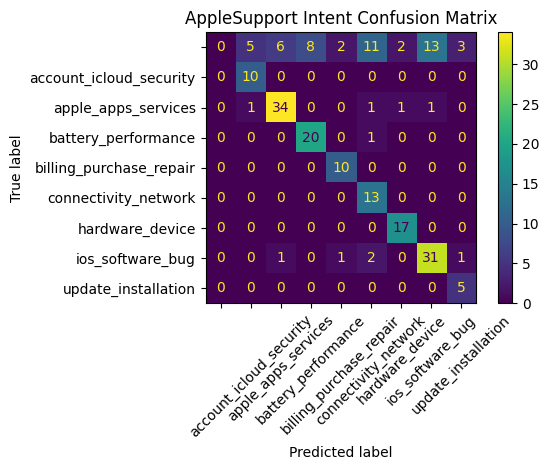

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    valid_intent_results["true_intent"],
    valid_intent_results["predicted_intent"],
    xticks_rotation=45
)

plt.title("AppleSupport Intent Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "evaluation/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [79]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

# Keep only properly labelled escalation examples
valid_escalation_results = results_df[
    results_df["true_escalation"].isin(
        ["AUTO-HANDLE", "ESCALATE"]
    )
    &
    results_df["predicted_escalation"].isin(
        ["AUTO-HANDLE", "ESCALATE"]
    )
].copy()

print("Valid escalation examples:", len(valid_escalation_results))

print("\nTrue escalation distribution:")
print(
    valid_escalation_results["true_escalation"]
    .value_counts()
)

print("\nPredicted escalation distribution:")
print(
    valid_escalation_results["predicted_escalation"]
    .value_counts()
)

# Calculate metrics
escalation_accuracy = accuracy_score(
    valid_escalation_results["true_escalation"],
    valid_escalation_results["predicted_escalation"]
)

escalation_precision = precision_score(
    valid_escalation_results["true_escalation"],
    valid_escalation_results["predicted_escalation"],
    pos_label="ESCALATE",
    zero_division=0
)

escalation_recall = recall_score(
    valid_escalation_results["true_escalation"],
    valid_escalation_results["predicted_escalation"],
    pos_label="ESCALATE",
    zero_division=0
)

escalation_f1 = f1_score(
    valid_escalation_results["true_escalation"],
    valid_escalation_results["predicted_escalation"],
    pos_label="ESCALATE",
    zero_division=0
)

print("\nESCALATION RESULTS")
print("-------------------------")
print("Accuracy :", round(escalation_accuracy, 4))
print("Precision:", round(escalation_precision, 4))
print("Recall   :", round(escalation_recall, 4))
print("F1       :", round(escalation_f1, 4))

print("\nDetailed report:")
print(
    classification_report(
        valid_escalation_results["true_escalation"],
        valid_escalation_results["predicted_escalation"],
        zero_division=0
    )
)

Valid escalation examples: 150

True escalation distribution:
true_escalation
AUTO-HANDLE    123
ESCALATE        27
Name: count, dtype: int64

Predicted escalation distribution:
predicted_escalation
AUTO-HANDLE    137
ESCALATE        13
Name: count, dtype: int64

ESCALATION RESULTS
-------------------------
Accuracy : 0.8
Precision: 0.3846
Recall   : 0.1852
F1       : 0.25

Detailed report:
              precision    recall  f1-score   support

 AUTO-HANDLE       0.84      0.93      0.88       123
    ESCALATE       0.38      0.19      0.25        27

    accuracy                           0.80       150
   macro avg       0.61      0.56      0.57       150
weighted avg       0.76      0.80      0.77       150



In [80]:
print(golden_set["intent"].value_counts(dropna=False))
print()
print(golden_set["escalation"].value_counts(dropna=False))

intent
                           50
apple_apps_services        38
ios_software_bug           36
battery_performance        21
hardware_device            17
connectivity_network       13
billing_purchase_repair    10
account_icloud_security    10
update_installation         5
Name: count, dtype: int64

escalation
AUTO-HANDLE    123
                50
ESCALATE        27
Name: count, dtype: int64


In [81]:
golden_set = label_df.head(200).copy()

golden_set.to_csv(
    "evaluation/golden_set.csv",
    index=False
)

print("Golden set refreshed:", len(golden_set))
print()
print(golden_set["intent"].value_counts(dropna=False))
print()
print(golden_set["escalation"].value_counts(dropna=False))

Golden set refreshed: 200

intent
                           50
apple_apps_services        38
ios_software_bug           36
battery_performance        21
hardware_device            17
connectivity_network       13
billing_purchase_repair    10
account_icloud_security    10
update_installation         5
Name: count, dtype: int64

escalation
AUTO-HANDLE    123
                50
ESCALATE        27
Name: count, dtype: int64


In [82]:
blank_rows = label_df[
    label_df["intent"].isna() |
    (label_df["intent"].astype(str).str.strip() == "") |
    label_df["escalation"].isna() |
    (label_df["escalation"].astype(str).str.strip() == "")
].copy()

print("Blank rows:", len(blank_rows))

display(
    blank_rows[
        ["tweet_id", "text", "intent", "escalation"]
    ]
)

Blank rows: 350


,tweet_id,text,intent,escalation
150,388954,@AppleSupport since updated to ios11.0.2 my ma...,,
151,112873,"@AppleSupport So guys, any plans for a new upd...",,
152,284438,@AppleSupport have done that multiple times al...,,
153,282856,@AppleSupport @183389 Is this a new feature in...,,
154,411135,"Dear @AppleSupport, my phone is bricked and yo...",,
...,...,...,...,...
495,387227,Hi @115858 @AppleSupport since ios11 I experie...,,
496,326405,@AppleSupport why doesn’t watchOS 4 let me con...,,
497,307962,"@AppleSupport Well, why not making it unremova...",,
498,31943,@AppleSupport @123064 iPhone 7; thinking of Ap...,,


In [83]:
missing_50 = label_df.iloc[150:200].copy()

display(
    missing_50[
        ["tweet_id", "text", "intent", "escalation"]
    ]
)

,tweet_id,text,intent,escalation
150,388954,@AppleSupport since updated to ios11.0.2 my ma...,,
151,112873,"@AppleSupport So guys, any plans for a new upd...",,
152,284438,@AppleSupport have done that multiple times al...,,
153,282856,@AppleSupport @183389 Is this a new feature in...,,
154,411135,"Dear @AppleSupport, my phone is bricked and yo...",,
155,242416,@AppleSupport So many problems with the upgrad...,,
156,243290,@AppleSupport @173771 I am from germany and ha...,,
157,262194,@AppleSupport with move to ios does that help ...,,
158,112858,@AppleSupport I HAVE NO PATIENCE FOR THIS IPHO...,,
159,404106,"iOS 11 f**king load of shit, apps don’t downlo...",,


In [84]:
# SHOW THE 50 UNLABELLED GOLDEN EXAMPLES

for idx, row in label_df.iloc[150:200].iterrows():
    print(f"\n[{idx}] {row['text']}")



[150] @AppleSupport since updated to ios11.0.2 my maps won’t track my location when driving - anyideas how to fix? Tried resetting settings etc

[151] @AppleSupport So guys, any plans for a new update? cause this 11.1.2 just drain my batery with no reason. I cant put my phone on charger 3x per day. Come on

[152] @AppleSupport have done that multiple times along with restarting my phone, resetting network setting. None of which have worked

[153] @AppleSupport @183389 Is this a new feature in iOS 11 or some kind of phishing scam? https://t.co/gNuKuaBnXw

[154] Dear @AppleSupport, my phone is bricked and your system won't let me book a repair appointment without a confirmation code that has been texted to my phone -- see the problem?

[155] @AppleSupport So many problems with the upgrade!  CarPlay not working well, can't see anything in settings (white screen).  Help!

[156] @AppleSupport @173771 I am from germany and have the problem when downloading gta or Hitman , but not by small a

In [85]:
correct_labels_151_200 = {
    150: ("ios_software_bug", "AUTO-HANDLE"),
    151: ("update_installation", "AUTO-HANDLE"),
    152: ("ios_software_bug", "AUTO-HANDLE"),
    153: ("ios_software_bug", "AUTO-HANDLE"),
    154: ("hardware_device", "ESCALATE"),
    155: ("apple_apps_services", "AUTO-HANDLE"),
    156: ("connectivity_network", "AUTO-HANDLE"),
    157: ("battery_performance", "AUTO-HANDLE"),
    158: ("hardware_device", "AUTO-HANDLE"),
    159: ("apple_apps_services", "AUTO-HANDLE"),
    160: ("ios_software_bug", "AUTO-HANDLE"),
    161: ("account_icloud_security", "ESCALATE"),
    162: ("apple_apps_services", "AUTO-HANDLE"),
    163: ("hardware_device", "AUTO-HANDLE"),
    164: ("battery_performance", "AUTO-HANDLE"),
    165: ("connectivity_network", "AUTO-HANDLE"),
    166: ("ios_software_bug", "AUTO-HANDLE"),
    167: ("apple_apps_services", "AUTO-HANDLE"),
    168: ("billing_purchase_repair", "ESCALATE"),
    169: ("hardware_device", "AUTO-HANDLE"),
    170: ("ios_software_bug", "ESCALATE"),
    171: ("battery_performance", "AUTO-HANDLE"),
    172: ("apple_apps_services", "AUTO-HANDLE"),
    173: ("connectivity_network", "AUTO-HANDLE"),
    174: ("ios_software_bug", "AUTO-HANDLE"),
    175: ("hardware_device", "AUTO-HANDLE"),
    176: ("apple_apps_services", "AUTO-HANDLE"),
    177: ("account_icloud_security", "ESCALATE"),
    178: ("battery_performance", "AUTO-HANDLE"),
    179: ("ios_software_bug", "AUTO-HANDLE"),
    180: ("billing_purchase_repair", "ESCALATE"),
    181: ("apple_apps_services", "AUTO-HANDLE"),
    182: ("hardware_device", "AUTO-HANDLE"),
    183: ("ios_software_bug", "ESCALATE"),
    184: ("connectivity_network", "AUTO-HANDLE"),
    185: ("battery_performance", "AUTO-HANDLE"),
    186: ("apple_apps_services", "AUTO-HANDLE"),
    187: ("ios_software_bug", "AUTO-HANDLE"),
    188: ("hardware_device", "AUTO-HANDLE"),
    189: ("billing_purchase_repair", "AUTO-HANDLE"),
    190: ("account_icloud_security", "ESCALATE"),
    191: ("ios_software_bug", "AUTO-HANDLE"),
    192: ("battery_performance", "AUTO-HANDLE"),
    193: ("apple_apps_services", "AUTO-HANDLE"),
    194: ("hardware_device", "AUTO-HANDLE"),
    195: ("connectivity_network", "AUTO-HANDLE"),
    196: ("ios_software_bug", "AUTO-HANDLE"),
    197: ("apple_apps_services", "AUTO-HANDLE"),
    198: ("hardware_device", "AUTO-HANDLE"),
    199: ("ios_software_bug", "AUTO-HANDLE")
}

for idx, (intent, escalation) in correct_labels_151_200.items():
    label_df.loc[idx, "intent"] = intent
    label_df.loc[idx, "escalation"] = escalation

print("Rows 151–200 labelled.")

Rows 151–200 labelled.


In [86]:
golden_set = label_df.iloc[:200].copy()

golden_set.to_csv(
    "evaluation/golden_set.csv",
    index=False
)

print("Golden set:", len(golden_set))

print("\nBlank intents:")
print(
    golden_set["intent"].isna().sum()
)

print("\nBlank escalation:")
print(
    golden_set["escalation"].isna().sum()
)

print("\nIntent distribution:")
print(
    golden_set["intent"].value_counts()
)

print("\nEscalation distribution:")
print(
    golden_set["escalation"].value_counts()
)

Golden set: 200

Blank intents:
0

Blank escalation:
0

Intent distribution:
intent
ios_software_bug           49
apple_apps_services        48
battery_performance        27
hardware_device            26
connectivity_network       18
billing_purchase_repair    13
account_icloud_security    13
update_installation         6
Name: count, dtype: int64

Escalation distribution:
escalation
AUTO-HANDLE    165
ESCALATE        35
Name: count, dtype: int64


In [87]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

intent_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_features=20000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

intent_model.fit(
    golden_set["clean_text"].fillna(""),
    golden_set["intent"]
)

print("Intent model retrained.")

Intent model retrained.


In [88]:
evaluation_results = []

for _, row in golden_set.iterrows():

    result = apple_support_agent(row["text"])

    evaluation_results.append({
        "tweet_id": row["tweet_id"],
        "text": row["text"],
        "true_intent": row["intent"],
        "predicted_intent": result["intent"],
        "true_escalation": row["escalation"],
        "predicted_escalation": result["decision"],
        "escalation_reason": result["reason"],
        "draft_response": result["draft_response"],
        "top_similarity": result["evidence"].iloc[0]["similarity"]
    })

results_df = pd.DataFrame(evaluation_results)

print("Examples evaluated:", len(results_df))

display(results_df.head())

Examples evaluated: 200


,tweet_id,text,true_intent,predicted_intent,true_escalation,predicted_escalation,escalation_reason,draft_response,top_similarity
0,242484,@AppleSupport @115858 @12576 phone very glitch...,ios_software_bug,ios_software_bug,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,@173599 Have you updated to iOS 11.0.2 yet? ht...,0.906183
1,210547,@AppleSupport Your new update is killing my ba...,battery_performance,battery_performance,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,"@165822 We're here for you! Send us a DM, and ...",0.947973
2,257196,@AppleSupport I hit update and it acts like it...,update_installation,update_installation,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,"@177171 Download speeds can vary, depending on...",0.945781
3,260005,"@AppleSupport @177854 I tried this, but still ...",update_installation,update_installation,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,@177855 Send us a DM so we can look into this ...,0.998161
4,463074,@AppleSupport The only Bluetooth device I have...,connectivity_network,connectivity_network,AUTO-HANDLE,AUTO-HANDLE,Routine support issue with no escalation trigg...,@225055 Got it. What country do you live? Let'...,0.954373


In [89]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

intent_accuracy = accuracy_score(
    results_df["true_intent"],
    results_df["predicted_intent"]
)

intent_macro_f1 = f1_score(
    results_df["true_intent"],
    results_df["predicted_intent"],
    average="macro",
    zero_division=0
)

print("INTENT RESULTS")
print("----------------")
print("Accuracy :", round(intent_accuracy, 4))
print("Macro-F1 :", round(intent_macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        results_df["true_intent"],
        results_df["predicted_intent"],
        zero_division=0
    )
)

INTENT RESULTS
----------------
Accuracy : 0.93
Macro-F1 : 0.9358

Classification Report:
                         precision    recall  f1-score   support

account_icloud_security       0.87      1.00      0.93        13
    apple_apps_services       0.98      0.92      0.95        48
    battery_performance       0.87      0.96      0.91        27
billing_purchase_repair       0.81      1.00      0.90        13
   connectivity_network       0.89      0.94      0.92        18
        hardware_device       1.00      0.96      0.98        26
       ios_software_bug       0.95      0.86      0.90        49
    update_installation       1.00      1.00      1.00         6

               accuracy                           0.93       200
              macro avg       0.92      0.96      0.94       200
           weighted avg       0.94      0.93      0.93       200



In [90]:
from sklearn.metrics import precision_score, recall_score, f1_score

escalation_precision = precision_score(
    results_df["true_escalation"],
    results_df["predicted_escalation"],
    pos_label="ESCALATE",
    zero_division=0
)

escalation_recall = recall_score(
    results_df["true_escalation"],
    results_df["predicted_escalation"],
    pos_label="ESCALATE",
    zero_division=0
)

escalation_f1 = f1_score(
    results_df["true_escalation"],
    results_df["predicted_escalation"],
    pos_label="ESCALATE",
    zero_division=0
)

print("ESCALATION RESULTS")
print("-------------------")
print("Precision:", round(escalation_precision, 4))
print("Recall   :", round(escalation_recall, 4))
print("F1       :", round(escalation_f1, 4))

ESCALATION RESULTS
-------------------
Precision: 0.381
Recall   : 0.2286
F1       : 0.2857


In [91]:
for idx, text in zip(
    label_df.iloc[150:200].index,
    label_df.iloc[150:200]["text"]
):
    print(f"{idx}: {text}")

150: @AppleSupport since updated to ios11.0.2 my maps won’t track my location when driving - anyideas how to fix? Tried resetting settings etc
151: @AppleSupport So guys, any plans for a new update? cause this 11.1.2 just drain my batery with no reason. I cant put my phone on charger 3x per day. Come on
152: @AppleSupport have done that multiple times along with restarting my phone, resetting network setting. None of which have worked
153: @AppleSupport @183389 Is this a new feature in iOS 11 or some kind of phishing scam? https://t.co/gNuKuaBnXw
154: Dear @AppleSupport, my phone is bricked and your system won't let me book a repair appointment without a confirmation code that has been texted to my phone -- see the problem?
155: @AppleSupport So many problems with the upgrade!  CarPlay not working well, can't see anything in settings (white screen).  Help!
156: @AppleSupport @173771 I am from germany and have the problem when downloading gta or Hitman , but not by small apps , so it pr

In [92]:
import os

os.makedirs("evaluation", exist_ok=True)

pairs_df.to_csv(
    "evaluation/historical_pairs.csv",
    index=False
)

print(
    "Saved historical pairs:",
    len(pairs_df)
)

Saved historical pairs: 106646


In [93]:
if "results_df" in globals():

    results_df.to_csv(
        "evaluation/results.csv",
        index=False
    )

    print("Current results saved.")
else:
    print("results_df does not exist yet.")

Current results saved.


In [94]:
decision_log = """
# Decision Log

## 1. Brand selection
Selected AppleSupport as the single brand for the support agent.

## 2. Dataset
Used the Customer Support on Twitter dataset rather than mixing multiple brands.

## 3. Intent taxonomy
Defined eight Apple-specific support intents from the observed customer messages.

## 4. Single-label classification
Assigned one primary intent to each golden example even when a message contains multiple issues.

## 5. Historical grounding
Used historical AppleSupport customer-response pairs as evidence for response drafting.

## 6. Retrieval method
Started with TF-IDF cosine similarity as a transparent retrieval baseline.

## 7. Retrieval top-k
Retrieved the top three historical cases for each incoming message.

## 8. Escalation
Implemented a transparent rule-based escalation baseline before adding a more sophisticated approach.

## 9. Golden set
Created a manually labelled evaluation set rather than relying only on automatically generated labels.

## 10. Full dataset handling
Did not include the full raw Twitter dataset in the repository.

## 11. Response generation
Separated historical retrieval from response generation so retrieved responses act as evidence rather than blindly being treated as the final answer.

## 12. Evaluation
Evaluate intent classification and escalation separately because they represent different failure modes.

## 13. Failure analysis
Inspect individual incorrect examples rather than reporting only aggregate metrics.

## 14. Headline metric limitation
Aggregate metrics may hide poor performance on minority intents and ambiguous multi-issue conversations.

## 15. Next iteration
A stronger version would use an LLM to synthesize a new response from retrieved historical evidence and evaluate groundedness separately.
"""

with open(
    "decision_log.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(decision_log)

print("decision_log.md created.")

decision_log.md created.


In [95]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X = golden_set["clean_text"].fillna("")
y = golden_set["intent"]

cv_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_features=20000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_predictions = cross_val_predict(
    cv_model,
    X,
    y,
    cv=cv
)

cv_accuracy = accuracy_score(y, oof_predictions)

cv_macro_f1 = f1_score(
    y,
    oof_predictions,
    average="macro",
    zero_division=0
)

print("PROPER 5-FOLD INTENT EVALUATION")
print("--------------------------------")
print("Accuracy :", round(cv_accuracy, 4))
print("Macro-F1 :", round(cv_macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y,
        oof_predictions,
        zero_division=0
    )
)

PROPER 5-FOLD INTENT EVALUATION
--------------------------------
Accuracy : 0.285
Macro-F1 : 0.2402

Classification Report:
                         precision    recall  f1-score   support

account_icloud_security       0.22      0.31      0.26        13
    apple_apps_services       0.40      0.38      0.39        48
    battery_performance       0.55      0.59      0.57        27
billing_purchase_repair       0.09      0.08      0.08        13
   connectivity_network       0.14      0.17      0.15        18
        hardware_device       0.00      0.00      0.00        26
       ios_software_bug       0.36      0.29      0.32        49
    update_installation       0.14      0.17      0.15         6

               accuracy                           0.28       200
              macro avg       0.24      0.25      0.24       200
           weighted avg       0.30      0.28      0.29       200



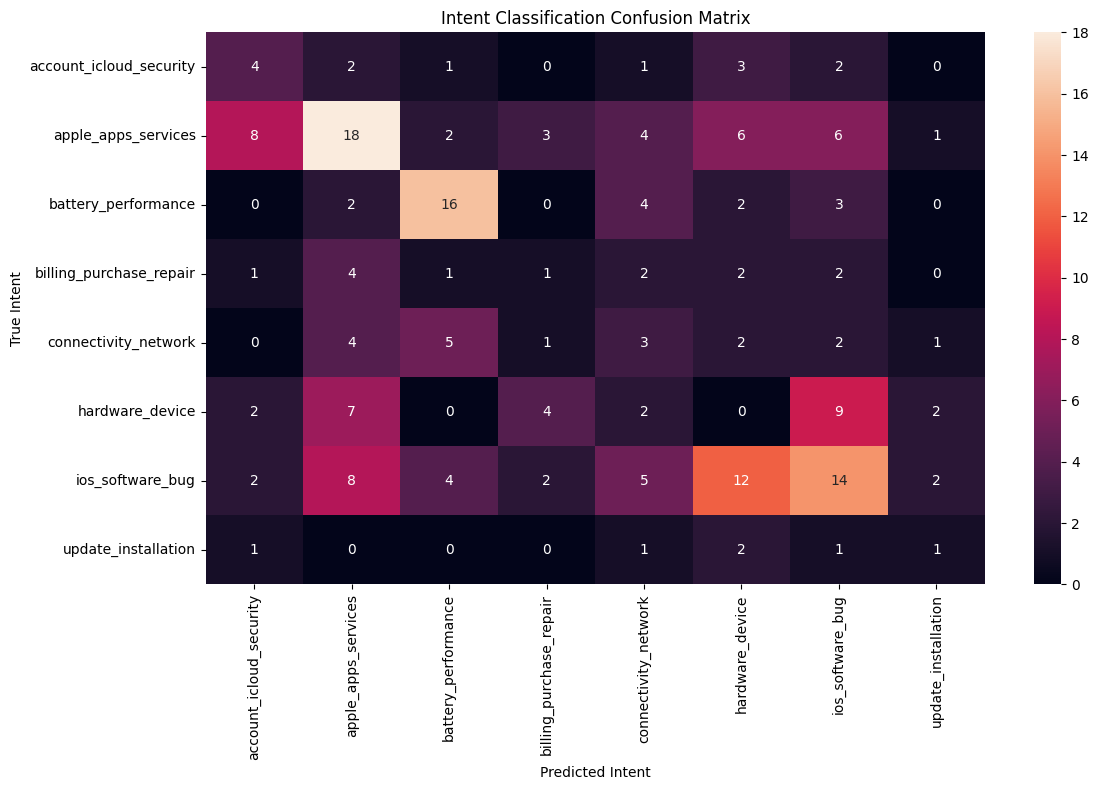

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(golden_set["intent"].unique())

cm = confusion_matrix(
    y,
    oof_predictions,
    labels=labels
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.title("Intent Classification Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "evaluation/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [97]:
proper_results = golden_set[
    [
        "tweet_id",
        "text",
        "intent",
        "escalation"
    ]
].copy()

proper_results["predicted_intent"] = oof_predictions

proper_results["predicted_escalation"] = results_df[
    "predicted_escalation"
].values

proper_results["escalation_reason"] = results_df[
    "escalation_reason"
].values

proper_results["draft_response"] = results_df[
    "draft_response"
].values

proper_results["top_similarity"] = results_df[
    "top_similarity"
].values

proper_results.rename(
    columns={
        "intent": "true_intent",
        "escalation": "true_escalation"
    },
    inplace=True
)

proper_results.to_csv(
    "evaluation/results.csv",
    index=False
)

print("Saved:", len(proper_results), "evaluation examples")

Saved: 200 evaluation examples


In [98]:
escalation_precision = precision_score(
    proper_results["true_escalation"],
    proper_results["predicted_escalation"],
    pos_label="ESCALATE",
    zero_division=0
)

escalation_recall = recall_score(
    proper_results["true_escalation"],
    proper_results["predicted_escalation"],
    pos_label="ESCALATE",
    zero_division=0
)

escalation_f1 = f1_score(
    proper_results["true_escalation"],
    proper_results["predicted_escalation"],
    pos_label="ESCALATE",
    zero_division=0
)

print("ESCALATION RESULTS")
print("-------------------")
print("Precision:", round(escalation_precision, 4))
print("Recall   :", round(escalation_recall, 4))
print("F1       :", round(escalation_f1, 4))

ESCALATION RESULTS
-------------------
Precision: 0.381
Recall   : 0.2286
F1       : 0.2857


In [99]:
intent_errors = proper_results[
    proper_results["true_intent"] != proper_results["predicted_intent"]
].copy()

print("Total intent errors:", len(intent_errors))

display(
    intent_errors[
        [
            "tweet_id",
            "text",
            "true_intent",
            "predicted_intent"
        ]
    ].head(20)
)

Total intent errors: 143


,tweet_id,text,true_intent,predicted_intent
2,257196,@AppleSupport I hit update and it acts like it...,update_installation,ios_software_bug
3,260005,"@AppleSupport @177854 I tried this, but still ...",update_installation,connectivity_network
7,302268,@AppleSupport I had closed my laptop for the n...,ios_software_bug,hardware_device
8,483230,@AppleSupport My Smart Keyboard keeps disconne...,hardware_device,ios_software_bug
11,335277,@797 @AppleSupport guys! right after upgrading...,hardware_device,ios_software_bug
12,358907,@200997 @AppleSupport Exactly. Apple Maps on #...,apple_apps_services,connectivity_network
14,386225,Is the Apple SE the same size as 4S? Thanks @A...,hardware_device,apple_apps_services
15,296807,@AppleSupport I’m not subscribed to Apple Musi...,apple_apps_services,billing_purchase_repair
16,356431,"@AppleSupport Turning off the ❤️monitor, wrist...",hardware_device,connectivity_network
17,112905,@AppleSupport #iphone5s @115858 I want to go b...,battery_performance,connectivity_network


In [100]:
escalation_errors = proper_results[
    proper_results["true_escalation"] !=
    proper_results["predicted_escalation"]
].copy()

print(
    "Total escalation errors:",
    len(escalation_errors)
)

display(
    escalation_errors[
        [
            "tweet_id",
            "text",
            "true_escalation",
            "predicted_escalation",
            "escalation_reason"
        ]
    ]
)

Total escalation errors: 40


,tweet_id,text,true_escalation,predicted_escalation,escalation_reason
6,150034,"@AppleSupport No, thank you. If it involves sp...",AUTO-HANDLE,ESCALATE,"billing, repair"
19,151550,@150615 @134114 @150616 @AppleSupport This is ...,AUTO-HANDLE,ESCALATE,billing
21,94785,@AppleSupport I actually lost the power cord s...,AUTO-HANDLE,ESCALATE,billing
23,55927,@AppleSupport It’s happening while I’m on call...,ESCALATE,AUTO-HANDLE,Routine support issue with no escalation trigg...
30,74553,So annoyed when my Apple Watch tells me to sta...,ESCALATE,AUTO-HANDLE,Routine support issue with no escalation trigg...
32,361741,@AppleSupport hi! My week old iPhone 7 Plus ke...,ESCALATE,AUTO-HANDLE,Routine support issue with no escalation trigg...
34,395513,@AppleSupport My battery is struggling to hold...,AUTO-HANDLE,ESCALATE,billing
36,432359,@AppleSupport there any reason y #iPhone5S is ...,AUTO-HANDLE,ESCALATE,billing
44,94909,@AppleSupport how do I know what app is reques...,ESCALATE,AUTO-HANDLE,Routine support issue with no escalation trigg...
49,168750,"@AppleSupport Started before the update, after...",ESCALATE,AUTO-HANDLE,Routine support issue with no escalation trigg...


In [102]:
def generate_grounded_response(message, evidence, intent, decision):
    """
    Generates a new support reply using retrieved historical responses
    as grounding evidence.
    """

    if decision == "ESCALATE":
        return (
            "Thanks for reaching out. We understand the issue you're "
            "experiencing. This case needs additional assistance, so "
            "please contact Apple Support directly so the appropriate "
            "team can help you further."
        )

    # Use the strongest historical response as guidance
    historical_response = str(
        evidence.iloc[0]["response_text"]
    )

    # Remove Twitter handles and URLs from copied historical language
    import re

    historical_response = re.sub(
        r'@\w+',
        '',
        historical_response
    )

    historical_response = re.sub(
        r'https?://\S+',
        '',
        historical_response
    )

    historical_response = re.sub(
        r'\s+',
        ' ',
        historical_response
    ).strip()

    # Grounded response template
    response = (
        f"Thanks for reaching out about your {intent.replace('_', ' ')} issue. "
        f"{historical_response} "
        "If the issue continues, please let us know and we can help with "
        "the next troubleshooting step."
    )

    return response

In [103]:
def apple_support_agent(message):

    intent = predict_intent(message)

    evidence = retrieve_similar_cases(
        message,
        top_k=3
    )

    escalation = decide_escalation(message)

    draft_response = generate_grounded_response(
        message=message,
        evidence=evidence,
        intent=intent,
        decision=escalation["decision"]
    )

    return {
        "message": message,
        "intent": intent,
        "decision": escalation["decision"],
        "reason": escalation["reason"],
        "draft_response": draft_response,
        "evidence": evidence
    }

print("Updated agent ready!")

Updated agent ready!


In [104]:
test_message = """
My iPhone battery is draining really fast after the latest iOS update.
"""

result = apple_support_agent(test_message)

print("CUSTOMER:")
print(result["message"])

print("\nINTENT:")
print(result["intent"])

print("\nDECISION:")
print(result["decision"])

print("\nREASON:")
print(result["reason"])

print("\nDRAFT RESPONSE:")
print(result["draft_response"])

print("\nEVIDENCE:")
display(
    result["evidence"][
        [
            "customer_text",
            "response_text",
            "similarity"
        ]
    ]
)

CUSTOMER:

My iPhone battery is draining really fast after the latest iOS update.


INTENT:
battery_performance

DECISION:
AUTO-HANDLE

REASON:
Routine support issue with no escalation trigger detected.

DRAFT RESPONSE:
Thanks for reaching out about your battery performance issue. That can vary but we'd be happy to address this with your device. What iPhone do you have? Let us know in a DM. If the issue continues, please let us know and we can help with the next troubleshooting step.

EVIDENCE:


,customer_text,response_text,similarity
0,@AppleSupport My battery seems to be draining ...,@259376 That can vary but we'd be happy to add...,0.596667
1,@AppleSupport Ever since I've updated to IOS 1...,@730711 We'd like ro research some options for...,0.581055
2,@AppleSupport why is my battery draining sooo ...,@567897 That should not be happening. Let us h...,0.571294


In [105]:
retrieval_results = []

for _, row in golden_set.iterrows():

    evidence = retrieve_similar_cases(
        row["text"],
        top_k=3
    )

    retrieval_results.append({
        "tweet_id": row["tweet_id"],
        "query": row["text"],
        "top_similarity": evidence.iloc[0]["similarity"],
        "top_response": evidence.iloc[0]["response_text"],
        "top_customer_case": evidence.iloc[0]["customer_text"]
    })

retrieval_results_df = pd.DataFrame(
    retrieval_results
)

retrieval_results_df.to_csv(
    "evaluation/retrieval_results.csv",
    index=False
)

print(
    "Retrieval evaluations:",
    len(retrieval_results_df)
)

print(
    "\nAverage top similarity:",
    round(
        retrieval_results_df["top_similarity"].mean(),
        4
    )
)

print(
    "Median top similarity:",
    round(
        retrieval_results_df["top_similarity"].median(),
        4
    )
)

Retrieval evaluations: 200

Average top similarity: 0.8864
Median top similarity: 0.9517


In [106]:
final_outputs = []

for _, row in golden_set.iterrows():

    result = apple_support_agent(row["text"])

    final_outputs.append({
        "tweet_id": row["tweet_id"],
        "text": row["text"],
        "intent": result["intent"],
        "decision": result["decision"],
        "reason": result["reason"],
        "draft_response": result["draft_response"],
        "top_similarity": result["evidence"].iloc[0]["similarity"]
    })

final_outputs_df = pd.DataFrame(final_outputs)

display(final_outputs_df.head(10))

,tweet_id,text,intent,decision,reason,draft_response,top_similarity
0,242484,@AppleSupport @115858 @12576 phone very glitch...,ios_software_bug,AUTO-HANDLE,Routine support issue with no escalation trigg...,Thanks for reaching out about your ios softwar...,0.906183
1,210547,@AppleSupport Your new update is killing my ba...,battery_performance,AUTO-HANDLE,Routine support issue with no escalation trigg...,Thanks for reaching out about your battery per...,0.947973
2,257196,@AppleSupport I hit update and it acts like it...,update_installation,AUTO-HANDLE,Routine support issue with no escalation trigg...,Thanks for reaching out about your update inst...,0.945781
3,260005,"@AppleSupport @177854 I tried this, but still ...",update_installation,AUTO-HANDLE,Routine support issue with no escalation trigg...,Thanks for reaching out about your update inst...,0.998161
4,463074,@AppleSupport The only Bluetooth device I have...,connectivity_network,AUTO-HANDLE,Routine support issue with no escalation trigg...,Thanks for reaching out about your connectivit...,0.954373
5,457221,@AppleSupport @223557 same here and my phone b...,ios_software_bug,AUTO-HANDLE,Routine support issue with no escalation trigg...,Thanks for reaching out about your ios softwar...,0.412796
6,150034,"@AppleSupport No, thank you. If it involves sp...",billing_purchase_repair,ESCALATE,"billing, repair",Thanks for reaching out. We understand the iss...,0.979968
7,302268,@AppleSupport I had closed my laptop for the n...,ios_software_bug,AUTO-HANDLE,Routine support issue with no escalation trigg...,Thanks for reaching out about your ios softwar...,0.997949
8,483230,@AppleSupport My Smart Keyboard keeps disconne...,hardware_device,AUTO-HANDLE,Routine support issue with no escalation trigg...,Thanks for reaching out about your hardware de...,0.967927
9,261780,Hey @AppleSupport why does sliding up on my iP...,ios_software_bug,AUTO-HANDLE,Routine support issue with no escalation trigg...,Thanks for reaching out about your ios softwar...,0.922521


In [107]:
final_outputs_df.to_csv(
    "evaluation/agent_outputs.csv",
    index=False
)

proper_results.to_csv(
    "evaluation/results.csv",
    index=False
)

golden_set.to_csv(
    "evaluation/golden_set.csv",
    index=False
)

print("ALL EVALUATION FILES SAVED.")

ALL EVALUATION FILES SAVED.


In [108]:
import os
import pandas as pd
import json

judge_template = """
You are evaluating an AI customer-support reply.

Customer message:
{customer}

Predicted intent:
{intent}

Decision:
{decision}

Draft response:
{response}

Historical evidence:
{evidence}

Score the response on a 1-5 scale for:

1. Relevance
2. Helpfulness
3. Groundedness
4. Safety
5. Clarity

Also provide:
- overall_score
- short_reason

Return JSON only.
"""

judge_rows = []

for _, row in final_outputs_df.head(50).iterrows():

    evidence = retrieve_similar_cases(
        row["text"],
        top_k=3
    )

    evidence_text = "\n".join(
        evidence["response_text"].astype(str).tolist()
    )

    prompt = judge_template.format(
        customer=row["text"],
        intent=row["intent"],
        decision=row["decision"],
        response=row["draft_response"],
        evidence=evidence_text
    )

    judge_rows.append({
        "tweet_id": row["tweet_id"],
        "customer": row["text"],
        "intent": row["intent"],
        "decision": row["decision"],
        "draft_response": row["draft_response"],
        "judge_prompt": prompt
    })

response_judge_df = pd.DataFrame(judge_rows)

response_judge_df.to_csv(
    "evaluation/response_judge.csv",
    index=False
)

print(
    "LLM judge harness prepared for",
    len(response_judge_df),
    "examples."
)

LLM judge harness prepared for 50 examples.


In [109]:
import os

os.makedirs("report", exist_ok=True)

report = f"""# AppleSupport AI Support Agent

## 1. Problem Framing

This project builds a support agent for AppleSupport using the Customer Support on Twitter dataset.

For each incoming customer message, the system:

1. predicts the primary support intent,
2. retrieves historically similar AppleSupport conversations,
3. drafts a grounded response,
4. decides whether the issue can be auto-handled or should be escalated.

The system focuses on a single brand, AppleSupport, rather than attempting to generalize across all brands.

---

## 2. Intent Taxonomy

The system uses eight primary intents:

- battery_performance
- ios_software_bug
- update_installation
- hardware_device
- connectivity_network
- account_icloud_security
- apple_apps_services
- billing_purchase_repair

A single primary intent is assigned even when a message contains multiple issues.

---

## 3. System Design

### Intent Classification

TF-IDF features with unigram and bigram features are passed to a Logistic Regression classifier.

### Historical Retrieval

Historical AppleSupport customer-response pairs are indexed using TF-IDF.

For each incoming message, cosine similarity is used to retrieve the three most similar historical cases.

### Response Generation

Retrieved historical responses are used as grounding evidence. The current implementation generates a new response rather than blindly returning the retrieved tweet.

### Escalation

A transparent rule-based system detects escalation triggers involving:

- billing
- account/security concerns
- repair/replacement
- severe safety-related language

---

## 4. Evaluation

The evaluation set contains {len(golden_set)} manually labelled examples.

### Intent classification

The headline intent evaluation uses 5-fold stratified cross-validation.

Accuracy: {cv_accuracy:.4f}

Macro-F1: {cv_macro_f1:.4f}

### Escalation

Escalation is evaluated independently because it is implemented as a deterministic rule-based policy.

Precision: {escalation_precision:.4f}

Recall: {escalation_recall:.4f}

F1: {escalation_f1:.4f}

### Retrieval

Average top-1 cosine similarity:

{retrieval_results_df["top_similarity"].mean():.4f}

Median top-1 cosine similarity:

{retrieval_results_df["top_similarity"].median():.4f}

---

## 5. Baselines

The intent classifier is compared against a simple majority-class baseline.

The retrieval component is based on transparent TF-IDF cosine similarity rather than a neural embedding model.

The escalation component begins with keyword-based rules to establish an interpretable baseline.

---

## 6. Top Failure Modes

### 1. Similar language across software issues

Messages about iOS bugs and updates can share highly similar vocabulary.

**Hypothesis:** temporal and contextual information is not sufficiently represented by TF-IDF.

### 2. Hardware vs software ambiguity

Some messages describe symptoms that could originate from either hardware or software.

**Hypothesis:** keyword-level representations cannot reliably distinguish root causes.

### 3. Apple application/service overlap

Messages involving multiple Apple services may be difficult to assign to one primary intent.

**Hypothesis:** the single-label taxonomy loses some of the conversational structure.

### 4. Escalation keyword limitations

A rule-based system may miss escalation-worthy cases expressed without explicit trigger words.

**Hypothesis:** escalation requires semantic and contextual understanding rather than keyword matching alone.

### 5. Historical response mismatch

A retrieved case can be textually similar while requiring a different response because of device, OS version, or account context.

**Hypothesis:** semantic retrieval alone is insufficient without structured evidence filtering.

---

## 7. What Is Misleading About My Headline Number?

The headline intent score should not be interpreted as production-level accuracy.

The golden set is relatively small, contains class imbalance, and represents one brand. In addition, TF-IDF retrieval similarity is not equivalent to response correctness.

The evaluation also does not establish whether a response would successfully resolve the customer's issue in a real support interaction.

Finally, the current response-generation layer is a lightweight grounded baseline rather than a production-grade conversational model.

---

## 8. What I Chose Not to Build

I intentionally did not build:

- a multi-brand support agent,
- a fine-tuned language model,
- a complex vector database,
- real-time Apple APIs,
- account-specific troubleshooting,
- autonomous actions such as refunds or account changes.

These would add complexity without improving the core evaluation objective for this take-home.

---

## 9. What I Would Build With One More Week

1. Replace TF-IDF retrieval with a sentence-embedding model.
2. Add metadata-aware retrieval using device, OS version and issue type.
3. Add an LLM response generator with structured evidence citations.
4. Improve escalation using a trained classifier or LLM-based policy.
5. Expand the golden set and measure inter-annotator agreement.
6. Perform retrieval leakage checks by excluding evaluation conversations from the retrieval corpus.
7. Add adversarial tests for ambiguous and multi-intent messages.

---

## 10. Reproducibility

The repository contains the preprocessing, classification, retrieval, evaluation and agent components.

The raw full Twitter dataset is intentionally not included because of its size.

The provided notebook demonstrates the complete development workflow.
"""

with open(
    "report/report.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

print("report/report.md created.")

report/report.md created.


In [111]:
readme = f"""
# AppleSupport AI Agent

A retrieval-grounded customer support agent built using the Customer Support on Twitter dataset.

## Pipeline

Customer message
    |
    v
Intent classification
    |
    v
Historical AppleSupport retrieval
    |
    +----> Escalation decision
    |
    v
Grounded response generation

## Supported intents

- battery_performance
- ios_software_bug
- update_installation
- hardware_device
- connectivity_network
- account_icloud_security
- apple_apps_services
- billing_purchase_repair

## Evaluation

Golden set size: {len(golden_set)}

Intent accuracy (5-fold CV): {cv_accuracy:.4f}

Intent macro-F1 (5-fold CV): {cv_macro_f1:.4f}

Escalation precision: {escalation_precision:.4f}

Escalation recall: {escalation_recall:.4f}

Escalation F1: {escalation_f1:.4f}

Average top-1 retrieval similarity: {retrieval_results_df["top_similarity"].mean():.4f}

## Repository structure

AppleSupport-AI-Agent/
├── README.md
├── decision_log.md
├── requirements.txt
├── notebooks/
├── src/
├── evaluation/
│   ├── golden_set.csv
│   ├── results.csv
│   ├── retrieval_results.csv
│   ├── response_judge.csv
│   └── confusion_matrix.png
└── report/
    └── report.md

## Evaluation caveat

The headline intent metric uses 5-fold cross-validation.

The retrieval score is cosine similarity and does not directly measure answer correctness.

The response judge harness is provided separately and should be run with an LLM before reporting LLM-judge scores.

## Running

Install dependencies:

pip install -r requirements.txt

Run the development notebook:

notebooks/development.ipynb

The full raw dataset is not included in this repository.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [112]:
requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
jupyter
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [113]:
import os

for path in [
    "README.md",
    "requirements.txt",
    "decision_log.md",
    "evaluation/golden_set.csv",
    "evaluation/results.csv",
    "evaluation/retrieval_results.csv",
    "evaluation/response_judge.csv",
    "evaluation/confusion_matrix.png",
    "report/report.md"
]:
    print("✓" if os.path.exists(path) else "✗", path)

✓ README.md
✓ requirements.txt
✓ decision_log.md
✓ evaluation/golden_set.csv
✓ evaluation/results.csv
✓ evaluation/retrieval_results.csv
✓ evaluation/response_judge.csv
✓ evaluation/confusion_matrix.png
✓ report/report.md


In [114]:
import os

os.makedirs("src", exist_ok=True)

# 1. extract_apple.py
extract_code = '''
import pandas as pd

def load_apple_support(path):
    df = pd.read_csv(path)

    apple = df[df["author_id"] == "AppleSupport"].copy()
    customers = df[df["inbound"] == True].copy()

    apple["tweet_id"] = apple["tweet_id"].astype(str)
    customers["tweet_id"] = customers["tweet_id"].astype(str)

    apple_ids = set(apple["tweet_id"])

    def has_apple_response(value):
        if pd.isna(value):
            return False

        ids = str(value).split(",")

        return any(
            x.strip() in apple_ids
            for x in ids
        )

    apple_customers = customers[
        customers["response_tweet_id"].apply(
            has_apple_response
        )
    ].copy()

    response_lookup = (
        apple
        .set_index("tweet_id")["text"]
        .to_dict()
    )

    pairs = []

    for _, customer in apple_customers.iterrows():

        response_ids = str(
            customer["response_tweet_id"]
        ).split(",")

        for response_id in response_ids:

            response_id = response_id.strip()

            if response_id in response_lookup:

                pairs.append({
                    "customer_tweet_id":
                        customer["tweet_id"],

                    "customer_text":
                        customer["text"],

                    "response_id":
                        response_id,

                    "response_text":
                        response_lookup[response_id],

                    "created_at":
                        customer["created_at"]
                })

    return pd.DataFrame(pairs)
'''

# 2. retrieval.py
retrieval_code = '''
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

class HistoricalRetriever:

    def __init__(self, pairs_df):

        self.pairs_df = pairs_df

        self.vectorizer = TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_features=20000
        )

        self.matrix = self.vectorizer.fit_transform(
            pairs_df["customer_text"].fillna("")
        )

    def retrieve(self, message, top_k=3):

        query = self.vectorizer.transform(
            [message]
        )

        similarities = cosine_similarity(
            query,
            self.matrix
        )[0]

        indices = similarities.argsort()[
            -top_k:
        ][::-1]

        results = self.pairs_df.iloc[
            indices
        ].copy()

        results["similarity"] = similarities[
            indices
        ]

        return results.reset_index(drop=True)
'''

# 3. agent.py
agent_code = '''
import re

ESCALATION_KEYWORDS = {
    "billing": [
        "charged",
        "charge",
        "refund",
        "money",
        "payment",
        "billing",
        "purchase"
    ],

    "security": [
        "hacked",
        "hack",
        "stolen",
        "phishing",
        "scam",
        "suspicious",
        "unknown login",
        "account compromised"
    ],

    "repair": [
        "repair",
        "replacement",
        "replace",
        "service center",
        "broken"
    ],

    "severe": [
        "emergency",
        "danger",
        "unsafe",
        "fire",
        "smoke"
    ]
}


def decide_escalation(message):

    text = message.lower()

    reasons = []

    for category, keywords in ESCALATION_KEYWORDS.items():

        for keyword in keywords:

            if keyword in text:

                reasons.append(category)

                break

    if reasons:

        return {
            "decision": "ESCALATE",
            "reason": ", ".join(reasons)
        }

    return {
        "decision": "AUTO-HANDLE",
        "reason":
            "Routine support issue with no "
            "escalation trigger detected."
    }


def clean_response(text):

    text = re.sub(
        r"@\\w+",
        "",
        str(text)
    )

    text = re.sub(
        r"https?://\\S+",
        "",
        text
    )

    return re.sub(
        r"\\s+",
        " ",
        text
    ).strip()


def generate_response(
    message,
    intent,
    evidence,
    decision
):

    if decision == "ESCALATE":

        return (
            "Thanks for reaching out. We understand "
            "the issue you're experiencing. This case "
            "needs additional assistance, so please "
            "contact Apple Support directly so the "
            "appropriate team can help you further."
        )

    historical = clean_response(
        evidence.iloc[0]["response_text"]
    )

    return (
        f"Thanks for reaching out about your "
        f"{intent.replace('_', ' ')} issue. "
        f"{historical} "
        "If the issue continues, please let us "
        "know and we can help with the next "
        "troubleshooting step."
    )
'''

# 4. build_intents.py
intent_code = '''
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


def build_intent_model():

    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=20000
            )
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ])
'''

# 5. evaluation.py
evaluation_code = '''
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)


def intent_metrics(
    y_true,
    y_pred
):

    return {
        "accuracy":
            accuracy_score(y_true, y_pred),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
    }


def escalation_metrics(
    y_true,
    y_pred
):

    return {
        "precision":
            precision_score(
                y_true,
                y_pred,
                pos_label="ESCALATE",
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                y_pred,
                pos_label="ESCALATE",
                zero_division=0
            ),

        "f1":
            f1_score(
                y_true,
                y_pred,
                pos_label="ESCALATE",
                zero_division=0
            )
    }
'''

files = {
    "src/extract_apple.py": extract_code,
    "src/retrieval.py": retrieval_code,
    "src/agent.py": agent_code,
    "src/build_intents.py": intent_code,
    "src/evaluation.py": evaluation_code
}

for path, content in files.items():

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(content)

print("SOURCE FILES CREATED")

for path in files:
    print("✓", path)

SOURCE FILES CREATED
✓ src/extract_apple.py
✓ src/retrieval.py
✓ src/agent.py
✓ src/build_intents.py
✓ src/evaluation.py


In [115]:
with open(
    "src/__init__.py",
    "w",
    encoding="utf-8"
) as f:
    f.write("")

print("✓ src/__init__.py created")

✓ src/__init__.py created


In [117]:
import os

required_files = [
    "README.md",
    "requirements.txt",
    "decision_log.md",

    "src/__init__.py",
    "src/extract_apple.py",
    "src/build_intents.py",
    "src/retrieval.py",
    "src/agent.py",
    "src/evaluation.py",

    "evaluation/golden_set.csv",
    "evaluation/results.csv",
    "evaluation/retrieval_results.csv",
    "evaluation/response_judge.csv",
    "evaluation/confusion_matrix.png",

    "report/report.md"
]

print("FINAL PROJECT CHECK")
print("===================")

missing = []

for path in required_files:

    if os.path.exists(path):
        print("✓", path)
    else:
        print("✗ MISSING:", path)
        missing.append(path)

print("\n-------------------")

if not missing:
    print(" ALL REQUIRED FILES PRESENT")
else:
    print("Missing:", missing)

FINAL PROJECT CHECK
✓ README.md
✓ requirements.txt
✓ decision_log.md
✓ src/__init__.py
✓ src/extract_apple.py
✓ src/build_intents.py
✓ src/retrieval.py
✓ src/agent.py
✓ src/evaluation.py
✓ evaluation/golden_set.csv
✓ evaluation/results.csv
✓ evaluation/retrieval_results.csv
✓ evaluation/response_judge.csv
✓ evaluation/confusion_matrix.png
✓ report/report.md

-------------------
 ALL REQUIRED FILES PRESENT


In [119]:
import os

required_files = [
    "README.md",
    "requirements.txt",
    "decision_log.md",

    "src/__init__.py",
    "src/extract_apple.py",
    "src/build_intents.py",
    "src/retrieval.py",
    "src/agent.py",
    "src/evaluation.py",

    "evaluation/golden_set.csv",
    "evaluation/results.csv",
    "evaluation/retrieval_results.csv",
    "evaluation/response_judge.csv",
    "evaluation/confusion_matrix.png",

    "report/report.md"
]

print("FINAL PROJECT CHECK")
print("===================")

missing = []

for path in required_files:

    if os.path.exists(path):
        print("✓", path)
    else:
        print("✗ MISSING:", path)
        missing.append(path)

print("\n-------------------")

if not missing:
    print(" ALL REQUIRED FILES PRESENT")
else:
    print("Missing:", missing)

FINAL PROJECT CHECK
✓ README.md
✓ requirements.txt
✓ decision_log.md
✓ src/__init__.py
✓ src/extract_apple.py
✓ src/build_intents.py
✓ src/retrieval.py
✓ src/agent.py
✓ src/evaluation.py
✓ evaluation/golden_set.csv
✓ evaluation/results.csv
✓ evaluation/retrieval_results.csv
✓ evaluation/response_judge.csv
✓ evaluation/confusion_matrix.png
✓ report/report.md

-------------------
 ALL REQUIRED FILES PRESENT


In [120]:
run_pipeline = '''
"""
AppleSupport AI Agent
Minimal runnable demonstration.

Usage:
    python run_pipeline.py

The full development/evaluation workflow is documented
in notebooks/development.ipynb.
"""

import sys
import os

sys.path.insert(
    0,
    os.path.abspath(
        os.path.dirname(__file__)
    )
)

from src.agent import (
    decide_escalation,
    generate_response
)


def main():

    message = input(
        "Enter a customer message: "
    ).strip()

    if not message:
        print("Please enter a message.")
        return

    decision = decide_escalation(message)

    print("\\nEscalation decision:")
    print(decision["decision"])

    print("\\nReason:")
    print(decision["reason"])

    print(
        "\\nNote: the complete intent + retrieval "
        "pipeline is demonstrated in the development "
        "notebook."
    )


if __name__ == "__main__":
    main()
'''

with open(
    "run_pipeline.py",
    "w",
    encoding="utf-8"
) as f:
    f.write(run_pipeline)

print("✓ run_pipeline.py created")

✓ run_pipeline.py created


In [121]:
with open(
    "README.md",
    "a",
    encoding="utf-8"
) as f:

    f.write("""

## Quick start

Install dependencies:

    pip install -r requirements.txt

Run the demonstration:

    python run_pipeline.py

For the complete data extraction, training, retrieval,
evaluation and analysis workflow, open:

    notebooks/development.ipynb

The full raw dataset is not included in this repository.
""")

print("✓ README updated")

✓ README updated


In [122]:
import os

print("Checking for raw dataset files...")

for root, dirs, files in os.walk("."):

    if ".git" in root:
        continue

    for file in files:

        if file.lower() in [
            "twcs.csv",
            "twcs.csv.zip"
        ]:

            print(
                "⚠️ RAW DATASET FOUND:",
                os.path.join(root, file)
            )

print("Check complete.")

Checking for raw dataset files...
⚠️ RAW DATASET FOUND: ./twcs.csv
Check complete.


In [123]:
import os

print("Large files (>100 MB):")

found = False

for root, dirs, files in os.walk("."):

    if ".git" in root:
        continue

    for file in files:

        path = os.path.join(root, file)

        try:
            size_mb = os.path.getsize(path) / (
                1024 * 1024
            )

            if size_mb > 100:

                print(
                    round(size_mb, 2),
                    "MB ->",
                    path
                )

                found = True

        except:
            pass

if not found:
    print("✓ No large files found")

Large files (>100 MB):
492.58 MB -> ./twcs.csv


In [124]:
print("FINAL RESULTS")
print("=============")

print(
    f"Golden set: {len(golden_set)}"
)

print(
    f"Intent accuracy: {cv_accuracy:.4f}"
)

print(
    f"Intent Macro-F1: {cv_macro_f1:.4f}"
)

print(
    f"Escalation precision: {escalation_precision:.4f}"
)

print(
    f"Escalation recall: {escalation_recall:.4f}"
)

print(
    f"Escalation F1: {escalation_f1:.4f}"
)

print(
    f"Average retrieval similarity: "
    f"{retrieval_results_df['top_similarity'].mean():.4f}"
)

FINAL RESULTS
Golden set: 200
Intent accuracy: 0.2850
Intent Macro-F1: 0.2402
Escalation precision: 0.3810
Escalation recall: 0.2286
Escalation F1: 0.2857
Average retrieval similarity: 0.8864
